## AirFly Insights: Data Visualization and Analysis of Airline Operations

Dataset link: https://www.kaggle.com/datasets/usdot/flight-delays/data 

Dataset Name: 2015 Flight Delays and Cancellations

### Milestone 1: Data Foundation and Cleaning

### Week 1: Project Initialization and Dataset Setup

• Define goals, KPIs, and workflow

• Load CSVs using pandas

• Explore schema, types, size, and nulls

• Perform sampling and memory optimizations

### Week 2: Preprocessing and Feature Engineering

• Handle nulls in delay and cancellation columns

• Create derived features: Month, Day of Week, Hour, Route

• Format datetime columns

• Save preprocessed data for fast reuse

### Deliverables:

• Cleaned dataset

• Summary of preprocessing logic

• Feature dictionary


### Loading CSVs using Pandas

In [ ]:
print("HI")

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')
flights = pd.read_csv('flights.csv')

In [2]:
print("Airlines:", airlines.shape)
print("Airports:", airports.shape)
print("Flights:", flights.shape)

Airlines: (14, 2)
Airports: (322, 7)
Flights: (5819079, 31)


### Explore schema, types, size, and nulls

In [3]:
print(flights.columns)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')


In [4]:
flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [6]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [7]:
flights['DEPARTURE_DELAY'].describe()

count    5.732926e+06
mean     9.370158e+00
std      3.708094e+01
min     -8.200000e+01
25%     -5.000000e+00
50%     -2.000000e+00
75%      7.000000e+00
max      1.988000e+03
Name: DEPARTURE_DELAY, dtype: float64

In [8]:
flights.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [9]:
flights['AIRLINE'].nunique()

14

In [10]:
flights['AIRLINE'].value_counts()

AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
NK     117379
F9      90836
HA      76272
VX      61903
Name: count, dtype: int64

In [11]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Memory Optimization

In [12]:
memory_before = flights.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before optimization: {memory_before:.2f} MB")

Memory before optimization: 2484.59 MB


In [13]:
def optimize_dtypes(df):
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in df.select_dtypes(include=['object']).columns:
        unique_ratio = df[col].nunique() / len(df)
        if unique_ratio < 0.5:
            df[col] = df[col].astype('category')
    return df

flights = optimize_dtypes(flights)
memory_after = flights.memory_usage(deep=True).sum() / 1024**2
print(f"Memory after optimization: {memory_after:.2f} MB")

Memory after optimization: 483.34 MB


### Handle nulls in delay and cancellation columns 

In [14]:
flights.isnull().sum().sort_values(ascending=False)


CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
MONTH                        0
ORIGIN_AIRPORT               0
SCHEDULED_DEPARTURE          0
YEAR                         0
SCHEDULED_ARRIVAL            0
DISTANCE                     0
DIVERTED                     0
CANCELLED                    0
dtype: int64

In [15]:
# Fill delay-related NaNs with 0
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
flights[delay_cols] = flights[delay_cols].fillna(0)

In [16]:
# Add 'Not Cancelled' as a valid category first
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].cat.add_categories(['Not Cancelled'])

# Now fill missing values safely
flights['CANCELLATION_REASON'].fillna('Not Cancelled', inplace=True)

In [17]:
flights['CANCELLATION_REASON'].value_counts() 

CANCELLATION_REASON
Not Cancelled    5729195
B                  48851
A                  25262
C                  15749
D                     22
Name: count, dtype: int64

In [18]:
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

In [19]:
flights['MONTH_NAME'] = flights['DATE'].dt.month_name()
flights['DAY_NAME'] = flights['DATE'].dt.day_name()
flights['SEASON'] = flights['MONTH'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})


In [20]:
flights['DATE'].head()

0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: DATE, dtype: datetime64[ns]

In [21]:
flights['DAY_NAME'] = flights['DATE'].dt.day_name()        # Monday, Tuesday, ...
flights['WEEK'] = flights['DATE'].dt.isocalendar().week    # ISO week number

In [22]:
flights.drop(['DAY', 'DAY_OF_WEEK', 'MONTH'], axis=1, inplace=True)

In [23]:
flights.shape

(5819079, 33)

In [24]:
flights.head()

,YEAR,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME,SEASON,WEEK
0,2015,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
1,2015,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
2,2015,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
3,2015,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
4,2015,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1


In [25]:
flights['ELAPSED_TIME'].isnull().sum()


np.int64(105071)

In [26]:
(flights['ELAPSED_TIME'] == 0).sum()
#checking for zeros (invalid for flights that actually operated)

np.int64(0)

In [27]:
#check for negatives (should NEVER exist):

(flights['ELAPSED_TIME'] < 0).sum()

np.int64(0)

In [28]:
flights[['TAXI_OUT', 'TAXI_IN']].isnull().sum()

TAXI_OUT    89047
TAXI_IN     92513
dtype: int64

In [29]:
#For cancelled or diverted flights: taxi times must be 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)

flights.loc[cancel_mask, ['TAXI_OUT', 'TAXI_IN']] = 0

In [30]:
#For valid flights with missing taxi values: fill with mean
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)

t_out_mean = flights.loc[valid_mask, 'TAXI_OUT'].mean()
t_in_mean = flights.loc[valid_mask, 'TAXI_IN'].mean()


In [31]:
flights[['TAXI_OUT', 'TAXI_IN']].isnull().sum()

TAXI_OUT    0
TAXI_IN     0
dtype: int64

In [32]:
'''Cancelled or diverted flights did not complete a gate-to-gate trip, so
ELAPSED_TIME should be 0
TAXI_OUT, TAXI_IN, AIR_TIME will be 0.'''
# For cancelled or diverted flights → ELAPSED_TIME must be 0
flights.loc[(flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1), 'ELAPSED_TIME'] = 0

# Mask for valid flights where ELAPSED_TIME is missing
mask = (
    flights['ELAPSED_TIME'].isnull() &
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0)
)

# Recalculate ELAPSED_TIME for valid flights
flights.loc[mask, 'ELAPSED_TIME'] = (
    flights.loc[mask, 'TAXI_OUT'] +
    flights.loc[mask, 'AIR_TIME'] +
    flights.loc[mask, 'TAXI_IN']
)



In [33]:
#Check for nulls in AIR_TIME
flights['AIR_TIME'].isnull().sum()

np.int64(105071)

In [34]:
flights.loc[(flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1), 'AIR_TIME'] = 0

In [35]:
import numpy as np

mask = (
    flights['AIR_TIME'].isnull() &
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0) &
    flights['ELAPSED_TIME'].notnull()
)

flights.loc[mask, 'AIR_TIME'] = (
    flights.loc[mask, 'ELAPSED_TIME'] -
    (flights.loc[mask, 'TAXI_OUT'].fillna(0) + flights.loc[mask, 'TAXI_IN'].fillna(0))
)

In [36]:
flights['AIR_TIME'].isnull().sum()

np.int64(0)

In [37]:
# No need of TAIL_NUMBER for our analysis, so drop TAIL_NUMBER
flights.drop('TAIL_NUMBER', axis=1, inplace=True)


In [38]:
# Null values count in ARRIVAL_DELAY
flights['ARRIVAL_DELAY'].isnull().sum()

np.int64(105071)

In [39]:
#Cancelled or diverted flights never arrived at destination → delay is 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'ARRIVAL_DELAY'] = 0

In [40]:
#For valid flights, fill missing ARRIVAL_DELAY with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
arrival_delay_median = flights.loc[valid_mask, 'ARRIVAL_DELAY'].median()

flights.loc[valid_mask, 'ARRIVAL_DELAY'] = (
    flights.loc[valid_mask, 'ARRIVAL_DELAY'].fillna(arrival_delay_median)
)

In [41]:
flights['ARRIVAL_DELAY'].isnull().sum()

np.int64(0)

In [42]:
#Checking for null valeues in DEPARTURE_DELAY
flights['DEPARTURE_DELAY'].isnull().sum()

np.int64(86153)

In [43]:
#Cancelled or diverted flights → DEPARTURE_DELAY = 0, Cancelled flights never departed.
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'DEPARTURE_DELAY'] = 0

In [44]:
#Filling missing values for valid flights using median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
departure_delay_median = flights.loc[valid_mask, 'DEPARTURE_DELAY'].median()

flights.loc[valid_mask, 'DEPARTURE_DELAY'] = (
    flights.loc[valid_mask, 'DEPARTURE_DELAY'].fillna(departure_delay_median)
)

In [45]:
flights['DEPARTURE_DELAY'].isnull().sum()

np.int64(0)

In [46]:
flights[['WHEELS_OFF', 'WHEELS_ON']].isnull().sum()

WHEELS_OFF    89047
WHEELS_ON     92513
dtype: int64

In [47]:
#Cancelled or diverted flights → set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, ['WHEELS_OFF', 'WHEELS_ON']] = 0

#Fill Null values for valid flights with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)

wheels_off_median = flights.loc[valid_mask, 'WHEELS_OFF'].median()
wheels_on_median  = flights.loc[valid_mask, 'WHEELS_ON'].median()

In [48]:
flights[['WHEELS_OFF', 'WHEELS_ON']].isnull().sum()

WHEELS_OFF    0
WHEELS_ON     0
dtype: int64

In [49]:
flights['ARRIVAL_TIME'].isnull().sum()
#Checking null values in ARRIVAL_TIME

np.int64(92513)

In [50]:
#Cancelled or diverted flights → Set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'ARRIVAL_TIME'] = 0

In [51]:
#For valid flights Filling missing values with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
arrival_time_median = flights.loc[valid_mask, 'ARRIVAL_TIME'].median()
flights.loc[valid_mask, 'ARRIVAL_TIME'] = (
    flights.loc[valid_mask, 'ARRIVAL_TIME'].fillna(arrival_time_median)
)

In [52]:
flights['ARRIVAL_TIME'].isnull().sum()

np.int64(0)

In [53]:
flights['DEPARTURE_TIME'].isnull().sum()
#Checking null values in DEPARTURE_TIME

np.int64(86153)

In [54]:
#Cancelled / Diverted flights → DEPARTURE_TIME = 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'DEPARTURE_TIME'] = 0

valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
departure_time_median = flights.loc[valid_mask, 'DEPARTURE_TIME'].median()

flights.loc[valid_mask, 'DEPARTURE_TIME'] = (
    flights.loc[valid_mask, 'DEPARTURE_TIME'].fillna(departure_time_median)
)

In [55]:
flights['DEPARTURE_TIME'].isnull().sum()

np.int64(0)

In [56]:
#Nan Values count in SCHEDULED_TIME
flights['SCHEDULED_TIME'].isnull().sum()

np.int64(6)

In [57]:
#Cancelled or diverted flights → set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'SCHEDULED_TIME'] = 0

In [58]:
flights.isnull().sum().sort_values(ascending=False)

YEAR                   0
AIRLINE                0
FLIGHT_NUMBER          0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
WHEELS_OFF             0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
WHEELS_ON              0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
MONTH_NAME             0
DAY_NAME               0
SEASON                 0
WEEK                   0
dtype: int64

### Perfroming Sampling

In [59]:
# The dataset is large, so we create a smaller version for smoother analysis.
# Sampling is done in a stratified way so each airline keeps its proportion.

# Choose the fraction of data you want to keep (2% is usually a good balance)
sample_fraction = 0.02  

# Perform stratified sampling grouped by airline
sample = (
    flights
    .groupby('AIRLINE')        # keep distribution across airlines
    .sample(frac=sample_fraction, random_state=42)
)

# Print the size of the sampled dataset
print("Sample shape:", sample.shape)

# Save the sampled data for quick loading later
sample.to_csv("flights_sample.csv", index=False)

print("Sampling complete. File saved as flights_sample.csv")

Sample shape: (116382, 32)
Sampling complete. File saved as flights_sample.csv


In [60]:
flights.columns

Index(['YEAR', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'MONTH_NAME', 'DAY_NAME', 'SEASON', 'WEEK'],
      dtype='object')

### Feature Engineering

In [61]:
# Convert to string to avoid Categorical + string error
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].astype(str)
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].astype(str)

# Now create the ROUTE column
flights['ROUTE'] = flights['ORIGIN_AIRPORT'] + " → " + flights['DESTINATION_AIRPORT']

In [62]:
# Extract hour from HHMM format
flights['DEPARTURE_HOUR'] = flights['DEPARTURE_TIME'] // 100
flights['ARRIVAL_HOUR'] = flights['ARRIVAL_TIME'] // 100

In [63]:
# Create IS_WEEKEND feature
flights['IS_WEEKEND'] = flights['DAY_NAME'].isin(['Saturday', 'Sunday']).astype(int)

In [64]:
# Create DELAY_CATEGORY feature
def categorize_delay(x):
    if x <= 0:
        return "On Time"
    elif x <= 15:
        return "Minor Delay"
    elif x <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

flights['DELAY_CATEGORY'] = flights['ARRIVAL_DELAY'].apply(categorize_delay)


In [65]:
# sum of all delay columns
delay_cols = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

flights['TOTAL_DELAY'] = flights[delay_cols].sum(axis=1)


In [66]:
# Distance bucketization (useful for correlation heatmaps)
def bucket_distance(d):
    if d < 300:
        return "Short Haul"
    elif d < 1500:
        return "Medium Haul"
    else:
        return "Long Haul"

flights['DISTANCE_BUCKET'] = flights['DISTANCE'].apply(bucket_distance)


In [67]:
# is flight departing night time 
flights['IS_RED_EYE'] = flights['DEPARTURE_HOUR'].between(22, 23) | flights['DEPARTURE_HOUR'].between(0, 4)
flights['IS_RED_EYE'] = flights['IS_RED_EYE'].astype(int)

In [68]:
# Avoid division by zero (AIR_TIME already cleaned)
flights['FLIGHT_SPEED'] = flights['DISTANCE'] / (flights['AIR_TIME'] / 60).replace(0, np.nan)
flights['FLIGHT_SPEED'] = flights['FLIGHT_SPEED'].fillna(0)

In [69]:
flights.columns

Index(['YEAR', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'MONTH_NAME', 'DAY_NAME', 'SEASON', 'WEEK',
       'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR', 'IS_WEEKEND',
       'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET', 'IS_RED_EYE',
       'FLIGHT_SPEED'],
      dtype='object')

In [70]:
flights.head()

,YEAR,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,WEEK,ROUTE,DEPARTURE_HOUR,ARRIVAL_HOUR,IS_WEEKEND,DELAY_CATEGORY,TOTAL_DELAY,DISTANCE_BUCKET,IS_RED_EYE,FLIGHT_SPEED
0,2015,AS,98,ANC,SEA,5,2354.0,-11.0,21.0,15.0,...,1,ANC → SEA,23.0,4.0,0,On Time,0.0,Medium Haul,1,514.082825
1,2015,AA,2336,LAX,PBI,10,2.0,-8.0,12.0,14.0,...,1,LAX → PBI,0.0,7.0,0,On Time,0.0,Long Haul,1,531.558960
2,2015,US,840,SFO,CLT,20,18.0,-2.0,16.0,34.0,...,1,SFO → CLT,0.0,8.0,0,Minor Delay,0.0,Long Haul,1,517.894714
3,2015,AA,258,LAX,MIA,20,15.0,-5.0,15.0,30.0,...,1,LAX → MIA,0.0,7.0,0,On Time,0.0,Long Haul,1,544.651123
4,2015,AS,135,SEA,ANC,25,24.0,-1.0,11.0,35.0,...,1,SEA → ANC,0.0,2.0,0,On Time,0.0,Medium Haul,1,436.582916


In [71]:
# Columns you want to remove
columns_to_drop = [
    'FLIGHT_NUMBER',
    'WHEELS_OFF',
    'WHEELS_ON',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL'
]
flights.drop(columns=columns_to_drop, inplace=True)

print("Dropped columns:", columns_to_drop)
print("Remaining columns:", flights.columns)


Dropped columns: ['FLIGHT_NUMBER', 'WHEELS_OFF', 'WHEELS_ON', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL']
Remaining columns: Index(['YEAR', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE', 'MONTH_NAME',
       'DAY_NAME', 'SEASON', 'WEEK', 'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR',
       'IS_WEEKEND', 'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET',
       'IS_RED_EYE', 'FLIGHT_SPEED'],
      dtype='object')


## Covariance

In [72]:
#1. Compute Covariance Between Two Columns
cov_value = flights['WEATHER_DELAY'].cov(flights['ARRIVAL_DELAY'])
print("Covariance:", cov_value)

Covariance: 92.61374598627202


In [73]:
#2. Covariance Matrix for All Delay Causes

delay_cols = ['ARRIVAL_DELAY','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','LATE_AIRCRAFT_DELAY','SECURITY_DELAY']

present = [c for c in delay_cols if c in flights.columns]  # for safety

cov_matrix = flights[present].cov()
print(cov_matrix)

                     ARRIVAL_DELAY  WEATHER_DELAY  LATE_AIRCRAFT_DELAY  \
ARRIVAL_DELAY          1514.732086      92.613746           498.929643   
WEATHER_DELAY            92.613746      77.571444             6.712220   
LATE_AIRCRAFT_DELAY     498.929643       6.712220           423.298243   
SECURITY_DELAY            1.002689      -0.005586             0.070445   

                     SECURITY_DELAY  
ARRIVAL_DELAY              1.002689  
WEATHER_DELAY             -0.005586  
LATE_AIRCRAFT_DELAY        0.070445  
SECURITY_DELAY             0.840497  


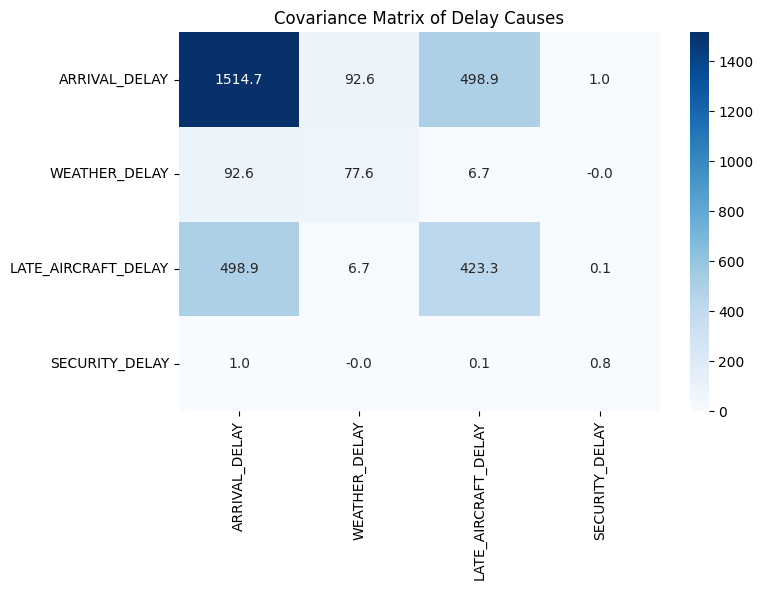

In [74]:
#3. Visualizing Covariance with Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cov_matrix, annot=True, fmt=".1f", cmap="Blues")
plt.title("Covariance Matrix of Delay Causes")
plt.tight_layout()
plt.show()

Arrival delays show the strongest covariance with late-aircraft delays, confirming that late incoming flights heavily influence subsequent delays. Weather and security delays exhibit very low covariance with all other delay types, indicating they occur independently. Overall, the matrix shows that operational chain effects (late aircraft), not weather, are the primary drivers of variation in arrival delay.


## Correlation & Collinearity

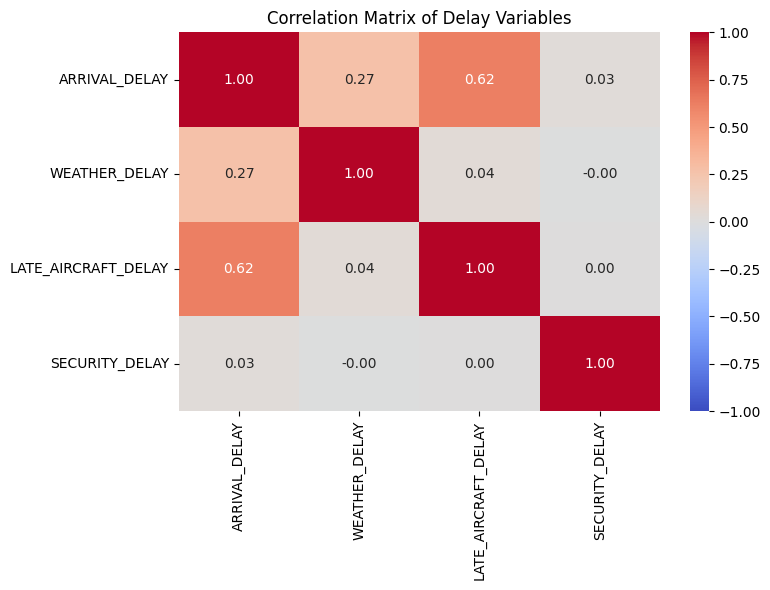

In [75]:
#Correlation Analysis (Pearson Correlation Matrix)
import seaborn as sns
import matplotlib.pyplot as plt

delay_cols = ['ARRIVAL_DELAY','CARRIER_DELAY','WEATHER_DELAY',
              'NAS_DELAY','LATE_AIRCRAFT_DELAY','SECURITY_DELAY']

# Keep only columns that exist
present = [c for c in delay_cols if c in flights.columns]

corr = flights[present].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Delay Variables")
plt.tight_layout()
plt.show()

Arrival delays show a strong positive correlation with late-aircraft delays, confirming that delayed incoming flights are the biggest driver of late arrivals. Weather and security delays have almost no correlation with other delay types, indicating they occur independently and affect flights unpredictably. Overall, the correlation matrix shows that operational chain reactions, not weather or security issues, have the greatest impact on delay patterns.


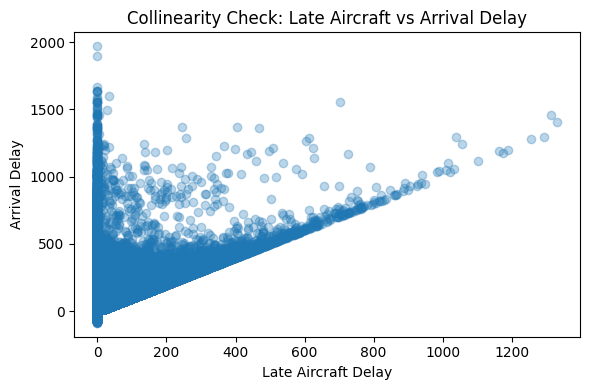

In [76]:
#Scatterplots for Pairwise Collinearity Check

plt.figure(figsize=(6,4))
plt.scatter(flights['LATE_AIRCRAFT_DELAY'], flights['ARRIVAL_DELAY'], alpha=0.3)
plt.xlabel("Late Aircraft Delay")
plt.ylabel("Arrival Delay")
plt.title("Collinearity Check: Late Aircraft vs Arrival Delay")
plt.tight_layout()
plt.show()

The scatter plot shows a clear upward trend, meaning arrival delay increases as late-aircraft delay increases. This strong collinearity indicates that delays often propagate from one flight to the next. In other words, late incoming aircraft are a major contributor to subsequent arrival delays, reinforcing the chain-reaction nature of airline operations.

----------------------

### Milestone 2: Visual Exploration and Delay Trends 

### Week 3: Univariate and Bivariate Visual Analysis 

• Top airlines, routes, and busiest months 

• Flight distribution by day, time, and airport 

• Plot bar charts, histograms, boxplots, and line plots 

### Week 4: Delay Analysis – Airline and Weather 

• Compare delay causes by airline 

• Explore carrier delays, weather delays, NAS delays 

• Visualize delays by time of day and airport 


### Deliverables:

• Set of visualizations (minimum 8) 

• Observations on peak delays and top delay-prone carriers

### Let's start with EDA

In [77]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 36 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int16         
 1   AIRLINE              category      
 2   ORIGIN_AIRPORT       object        
 3   DESTINATION_AIRPORT  object        
 4   DEPARTURE_TIME       float32       
 5   DEPARTURE_DELAY      float32       
 6   TAXI_OUT             float32       
 7   SCHEDULED_TIME       float32       
 8   ELAPSED_TIME         float32       
 9   AIR_TIME             float32       
 10  DISTANCE             int16         
 11  TAXI_IN              float32       
 12  ARRIVAL_TIME         float32       
 13  ARRIVAL_DELAY        float32       
 14  DIVERTED             int8          
 15  CANCELLED            int8          
 16  CANCELLATION_REASON  category      
 17  AIR_SYSTEM_DELAY     float32       
 18  SECURITY_DELAY       float32       
 19  AIRLINE_DELAY        

In [78]:
flights.describe()

,YEAR,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,TAXI_IN,ARRIVAL_TIME,...,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,WEEK,DEPARTURE_HOUR,ARRIVAL_HOUR,IS_WEEKEND,TOTAL_DELAY,IS_RED_EYE,FLIGHT_SPEED
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,...,5.819079e+06,5.819079e+06,5819079,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06
mean,2015.0,1.310959e+03,9.127011e+00,1.577541e+01,1.393319e+02,1.345324e+02,1.114620e+02,8.223565e+02,7.294922e+00,1.449716e+03,...,4.289670e+00,5.327704e-01,2015-07-01 21:46:24.656542976,26.997184,1.281322e+01,1.420688e+01,2.609191e-01,1.076663e+01,5.891998e-02,4.013437e+02
min,2015.0,0.000000e+00,-8.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,2015-01-01 00:00:00,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,9.060000e+02,-5.000000e+00,1.100000e+01,8.500000e+01,8.100000e+01,5.900000e+01,3.730000e+02,4.000000e+00,1.044000e+03,...,0.000000e+00,0.000000e+00,2015-04-04 00:00:00,14.0,9.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.631035e+02
50%,2015.0,1.320000e+03,-1.000000e+00,1.400000e+01,1.210000e+02,1.170000e+02,9.300000e+01,6.470000e+02,6.000000e+00,1.502000e+03,...,0.000000e+00,0.000000e+00,2015-07-02 00:00:00,27.0,1.300000e+01,1.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.139062e+02
75%,2015.0,1.736000e+03,7.000000e+00,1.900000e+01,1.720000e+02,1.670000e+02,1.430000e+02,1.062000e+03,9.000000e+00,1.912000e+03,...,0.000000e+00,0.000000e+00,2015-09-29 00:00:00,40.0,1.700000e+01,1.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,4.550000e+02
max,2015.0,2.400000e+03,1.988000e+03,2.250000e+02,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.480000e+02,2.400000e+03,...,1.331000e+03,1.211000e+03,2015-12-31 00:00:00,53.0,2.400000e+01,2.400000e+01,1.000000e+00,1.971000e+03,1.000000e+00,7.878688e+02
std,0.0,5.230539e+02,3.657611e+01,9.058117e+00,7.698544e+01,7.576709e+01,7.315421e+01,6.077843e+02,5.655182e+00,5.570446e+02,...,2.057421e+01,8.807466e+00,NaN,14.8697,5.226896e+00,5.557400e+00,4.391359e-01,3.567634e+01,2.354749e-01,8.773317e+01


In [79]:
flights.describe(include='object')

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,MONTH_NAME,DAY_NAME,SEASON,ROUTE,DELAY_CATEGORY,DISTANCE_BUCKET
count,5819079,5819079,5819079,5819079,5819079,5819079,5819079,5819079
unique,628,629,12,7,4,8609,4,3
top,ATL,ATL,July,Thursday,Summer,SFO → LAX,On Time,Medium Haul
freq,346836,346904,520718,872521,1535151,13744,3732183,4040667


In [80]:
flights.isnull().sum()

YEAR                   0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
TAXI_IN                0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
MONTH_NAME             0
DAY_NAME               0
SEASON                 0
WEEK                   0
ROUTE                  0
DEPARTURE_HOUR         0
ARRIVAL_HOUR           0
IS_WEEKEND             0
DELAY_CATEGORY         0
TOTAL_DELAY            0
DISTANCE_BUCKET        0
IS_RED_EYE             0
FLIGHT_SPEED           0
dtype: int64

### UNIVARIATE ANALYSIS

In [81]:
import matplotlib.pyplot as plt

### 1. Airline-wise Flight Count and Percentage Contribution

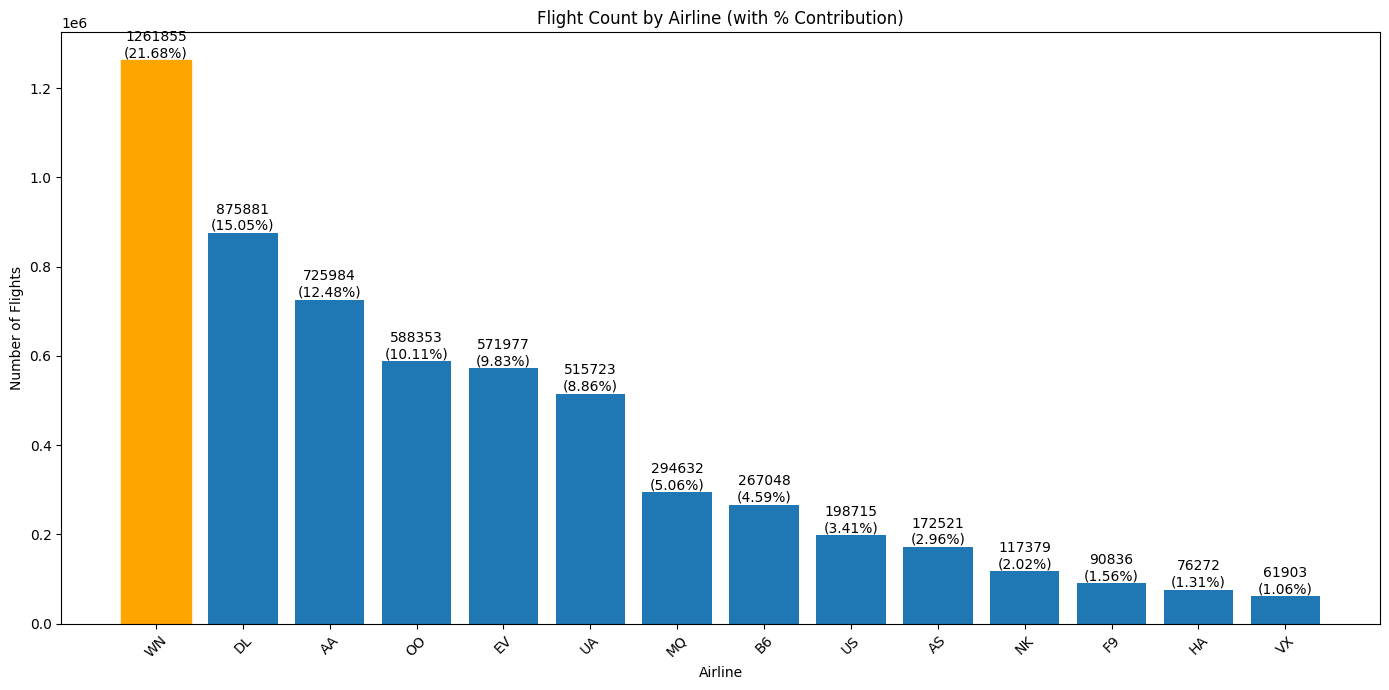

In [82]:
import matplotlib.pyplot as plt
# Count flights per airline
airline_counts = flights['AIRLINE'].value_counts()
airline_percent = (airline_counts / airline_counts.sum() * 100).round(2)
plt.figure(figsize=(14,7))

bars = plt.bar(airline_counts.index, airline_counts.values)
# Highlight top airline in a different color
bars[0].set_color('orange')

plt.title('Flight Count by Airline (with % Contribution)')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')

# Annotate each bar with exact count and percentage
for i, (count, pct) in enumerate(zip(airline_counts.values, airline_percent.values)):
    plt.text(i, count + 50, f"{count}\n({pct}%)", 
             ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [83]:
'''These numbers are fractions, not counts.
0.2 = 20% of total flights
0.4 = 40% of total flights
0.6 = 60% of total flights'''

'These numbers are fractions, not counts.\n0.2 = 20% of total flights\n0.4 = 40% of total flights\n0.6 = 60% of total flights'

### 2. Top 15 airlines by flight count(busiest routes)

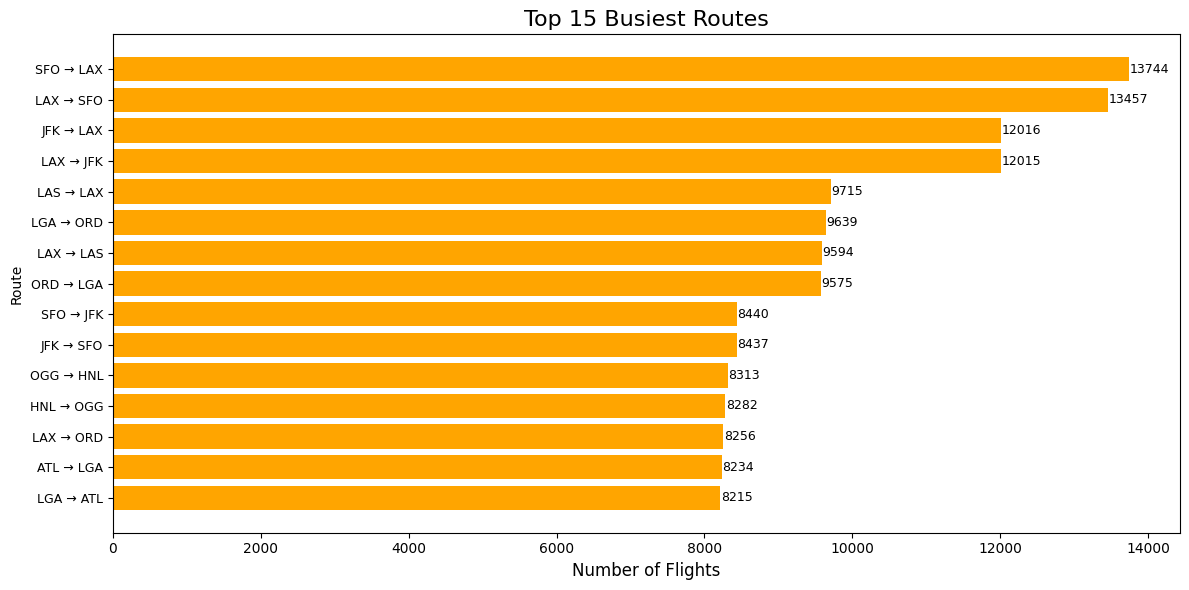

In [84]:
#Top 15 airlines by flight count
# Calculate top 15 busiest routes and sort them descending
top_routes = flights['ROUTE'].value_counts().head(15).sort_values()

plt.figure(figsize=(12,6))  

# Horizontal bar chart
plt.barh(top_routes.index, top_routes.values, color='orange')

# Title and labels

plt.title('Top 15 Busiest Routes', fontsize=16)
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Route', fontsize=10)

# Add data labels at the end of bars
for index, value in enumerate(top_routes.values):
    plt.text(value + 5, index, str(value), va='center', fontsize=9)

# Clean ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()


* The chart shows that a few airlines drive most of the flight activity, with WN alone contributing over one-fifth of all flights. This concentration means that any system-wide patterns or delays are likely shaped primarily by the operational behavior of these top carriers.

In [85]:
print(airlines)

   IATA_CODE                       AIRLINE
0         UA         United Air Lines Inc.
1         AA        American Airlines Inc.
2         US               US Airways Inc.
3         F9        Frontier Airlines Inc.
4         B6               JetBlue Airways
5         OO         Skywest Airlines Inc.
6         AS          Alaska Airlines Inc.
7         NK              Spirit Air Lines
8         WN        Southwest Airlines Co.
9         DL          Delta Air Lines Inc.
10        EV   Atlantic Southeast Airlines
11        HA        Hawaiian Airlines Inc.
12        MQ  American Eagle Airlines Inc.
13        VX                Virgin America


In [86]:
print(airports)

    IATA_CODE                              AIRPORT  \
0         ABE  Lehigh Valley International Airport   
1         ABI             Abilene Regional Airport   
2         ABQ    Albuquerque International Sunport   
3         ABR            Aberdeen Regional Airport   
4         ABY   Southwest Georgia Regional Airport   
..        ...                                  ...   
317       WRG                     Wrangell Airport   
318       WYS               Westerly State Airport   
319       XNA  Northwest Arkansas Regional Airport   
320       YAK                      Yakutat Airport   
321       YUM           Yuma International Airport   

                               CITY STATE COUNTRY  LATITUDE  LONGITUDE  
0                         Allentown    PA     USA  40.65236  -75.44040  
1                           Abilene    TX     USA  32.41132  -99.68190  
2                       Albuquerque    NM     USA  35.04022 -106.60919  
3                          Aberdeen    SD     USA  45.44906

In [87]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


### 3. Flight Volume by month

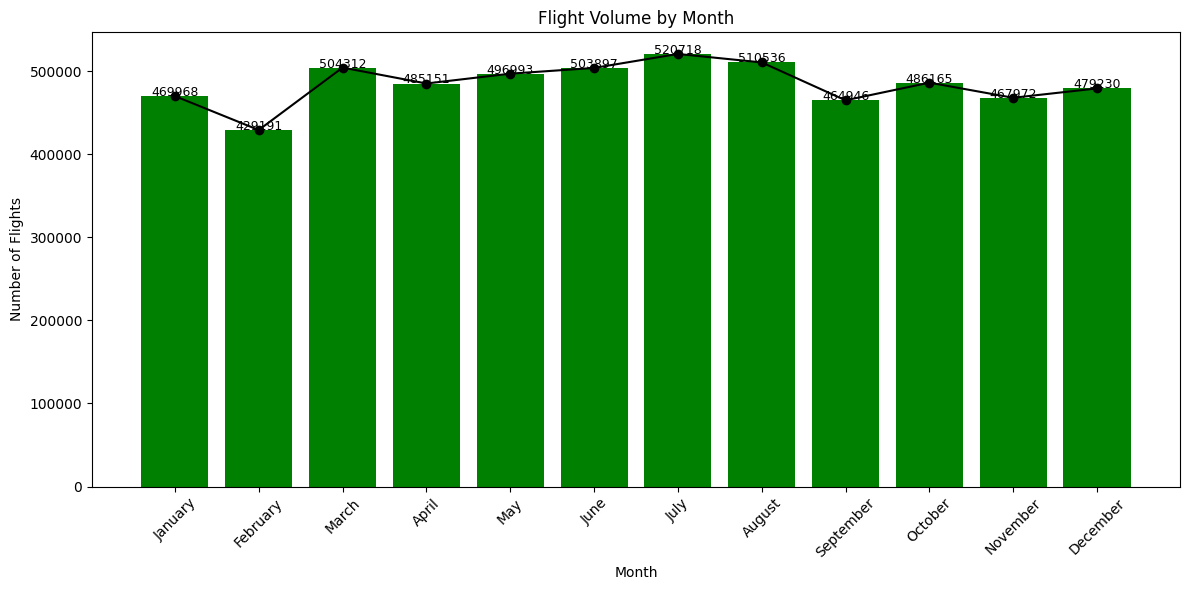

In [88]:
#Flight volume by month
# Count flights per month in calendar order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
month_counts = flights['MONTH_NAME'].value_counts().reindex(month_order)

plt.figure(figsize=(12,6))

# Bar chart
plt.bar(month_order, month_counts.values, color='green')

# Line chart on top of bars
plt.plot(month_order, month_counts.values, color='black', marker='o')

# Title and labels
plt.title('Flight Volume by Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

# Rotate x labels if needed
plt.xticks(rotation=45)

# Add numbers above the line points
for i, value in enumerate(month_counts.values):
    plt.text(i, value + 20, str(value), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

* Flight volume stays fairly consistent throughout the year, but activity clearly rises during the summer months, peaking in July. The dip in February and September suggests seasonal slowdowns, likely tied to reduced travel demand after holiday and summer peaks.

### 4. Distribution of Flights by day of week

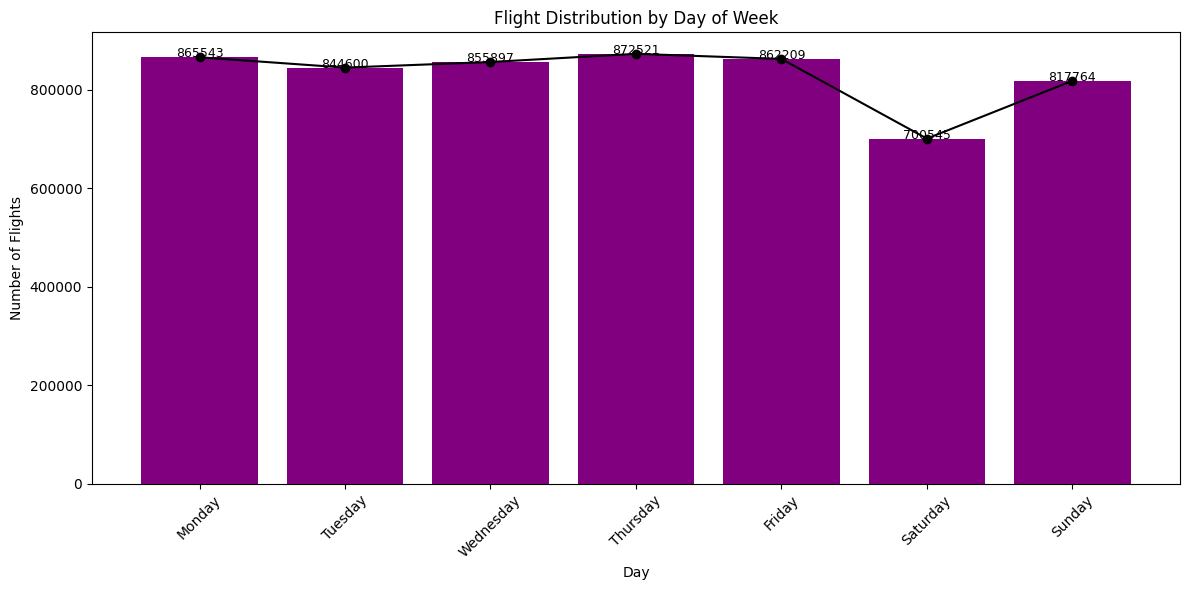

In [89]:
#4.Distribution by Day of Week
# Order days properly
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# Count flights in that order
day_counts = flights['DAY_NAME'].value_counts().reindex(day_order)

plt.figure(figsize=(12,6))
plt.bar(day_order, day_counts.values, color='purple')

# Line on top for weekly trend
plt.plot(day_order, day_counts.values, color='black', marker='o')

# Title and labels
plt.title('Flight Distribution by Day of Week')
plt.ylabel('Number of Flights')
plt.xlabel('Day')

# Add values above points
for i, value in enumerate(day_counts.values):
    plt.text(i, value + 20, str(value), ha='center', fontsize=9)

# Rotate labels if needed
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Flight activity stays fairly stable from Monday to Friday, with Thursday showing the highest volume. There is a sharp drop on Saturday, suggesting reduced weekend travel demand, followed by a moderate recovery on Sunday. This pattern indicates strong weekday business travel with lighter weekend operations.

### 5. Distribution of Flights on Weekdays and Weekends

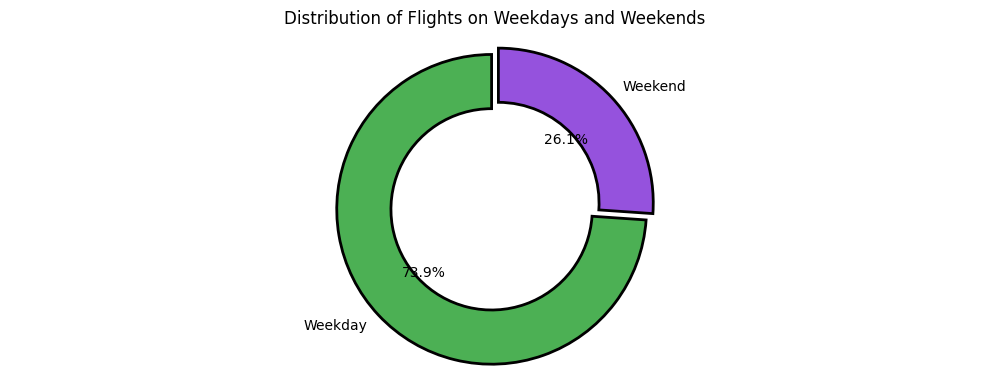

In [90]:
import seaborn as sns

plt.figure(figsize=(10, 4))

# Count of weekday vs weekend flights
weekend_counts = flights['IS_WEEKEND'].value_counts()

# Descriptive labels
labels = ['Weekday' if label == False else 'Weekend' for label in weekend_counts.index]

# Colors
colors = ["#4CB054", "#9552DD"] 

# Donut Chart
plt.pie(
    weekend_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.35, 'edgecolor': 'black', 'linewidth': 2},
    explode=(0.06, 0)
)

plt.title('Distribution of Flights on Weekdays and Weekends')
plt.axis('equal')
plt.tight_layout()
plt.show()


*Explanation:*

Most flights operate on weekdays, accounting for nearly three-quarters of total air traffic. Weekends see significantly fewer flights. This suggests airlines schedule more operations during business-heavy weekdays when travel demand is higher. The drop in weekend flights indicates lighter travel patterns or reduced scheduling requirements during those days.

### 6. Departure Hour Distribution (Histogram)

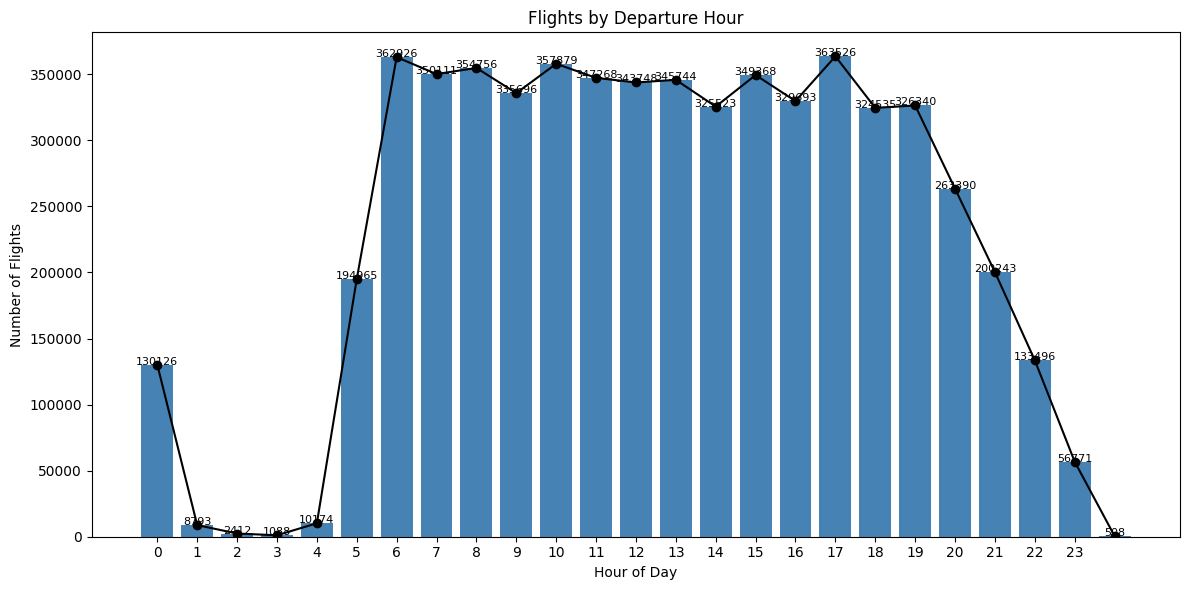

In [91]:
#6. Departure Hour Distribution (Histogram)
# Count flights per hour (0–23)
hour_counts = flights['DEPARTURE_HOUR'].value_counts().sort_index()

plt.figure(figsize=(12,6))

# Histogram-style bar chart (bars)
plt.bar(hour_counts.index, hour_counts.values, color='steelblue')

# Line on top to show trend clearly
plt.plot(hour_counts.index, hour_counts.values, color='black', marker='o')

# Title and labels
plt.title('Flights by Departure Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')

# Add numbers above line points
for i, value in enumerate(hour_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=8)

plt.xticks(range(24))  # show all hours clearly

plt.tight_layout()
plt.show()

* Flight activity is extremely low during late-night hours and starts rising sharply around 5 AM. The busiest period spans from 6 AM to 6 PM, indicating strong daytime travel demand. After 8 PM, departures drop quickly, showing that most flights are concentrated within standard daytime operating hours.

### 7. Arrival Hour Distribution(Histogram)

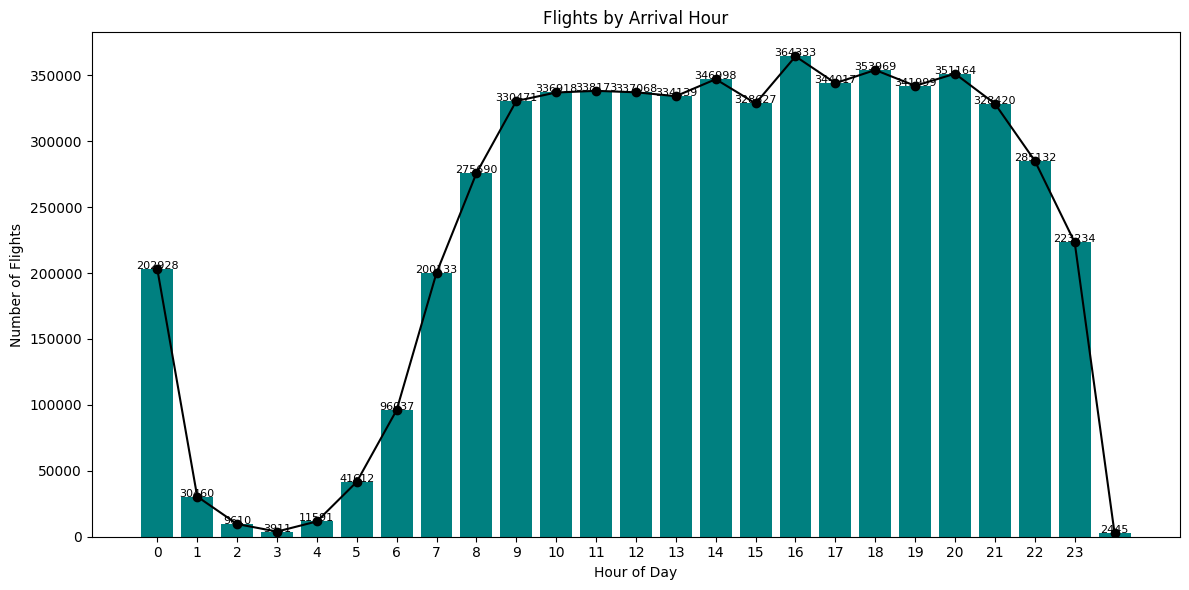

In [92]:
#7. Arrival Hour Distribution (Histogram)
# Count flights per arrival hour (0–23)
arrival_counts = flights['ARRIVAL_HOUR'].value_counts().sort_index()

plt.figure(figsize=(12,6))

# Bar chart (looks like a histogram but cleaner)
plt.bar(arrival_counts.index, arrival_counts.values, color='teal')

# Line on top to show trend
plt.plot(arrival_counts.index, arrival_counts.values, color='black', marker='o')

# Title and labels
plt.title('Flights by Arrival Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')

# Add value labels above points
for i, value in enumerate(arrival_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=8)

plt.xticks(range(24))  # show all hours clearly

plt.tight_layout()
plt.show()


* Arrivals follow a strong daytime pattern, with minimal flights late at night and a rapid increase starting around 6 AM. The busiest arrival period runs from 9 AM to 7 PM, showing sustained high traffic throughout the day. After 8 PM, arrivals steadily decline, indicating fewer evening operations.

Departure vs Arrival Hour Flight Patterns

Your two charts reveal several consistent and important patterns in flight operations. Here is a concise interpretation:

1. Activity builds up after early morning

Both departure and arrival counts are very low between 1 AM and 4 AM, which is normal because most commercial airlines avoid late-night operations. Activity starts increasing after 5 AM.

2. Sharp rise during morning hours

Departures rise faster than arrivals between 5 AM and 8 AM.
This shows that morning is a preferred time for airlines to schedule flights, and early departures directly drive the arrival peaks that follow.

3. Midday to evening hours show the highest traffic

Both charts stabilize at high volume from roughly 9 AM to 6 PM.
Arrivals tend to peak slightly after the departure peaks, which makes sense because flights take time to reach their destination.

4. Slight shift in peak timings

Departure peaks are strongest around 6 AM and 17 PM.

Arrival peaks shift a bit later, around 17 PM and 20 PM, because arrivals naturally lag behind departures.

5. Decline in late-night operations

Both charts show a gradual drop after 8 PM, with very few flights by 23 PM.
This pattern is typical due to airport noise restrictions and lower demand at night.

### Comparison of Delayed vs On-Time/Early Flights by Departure Hour

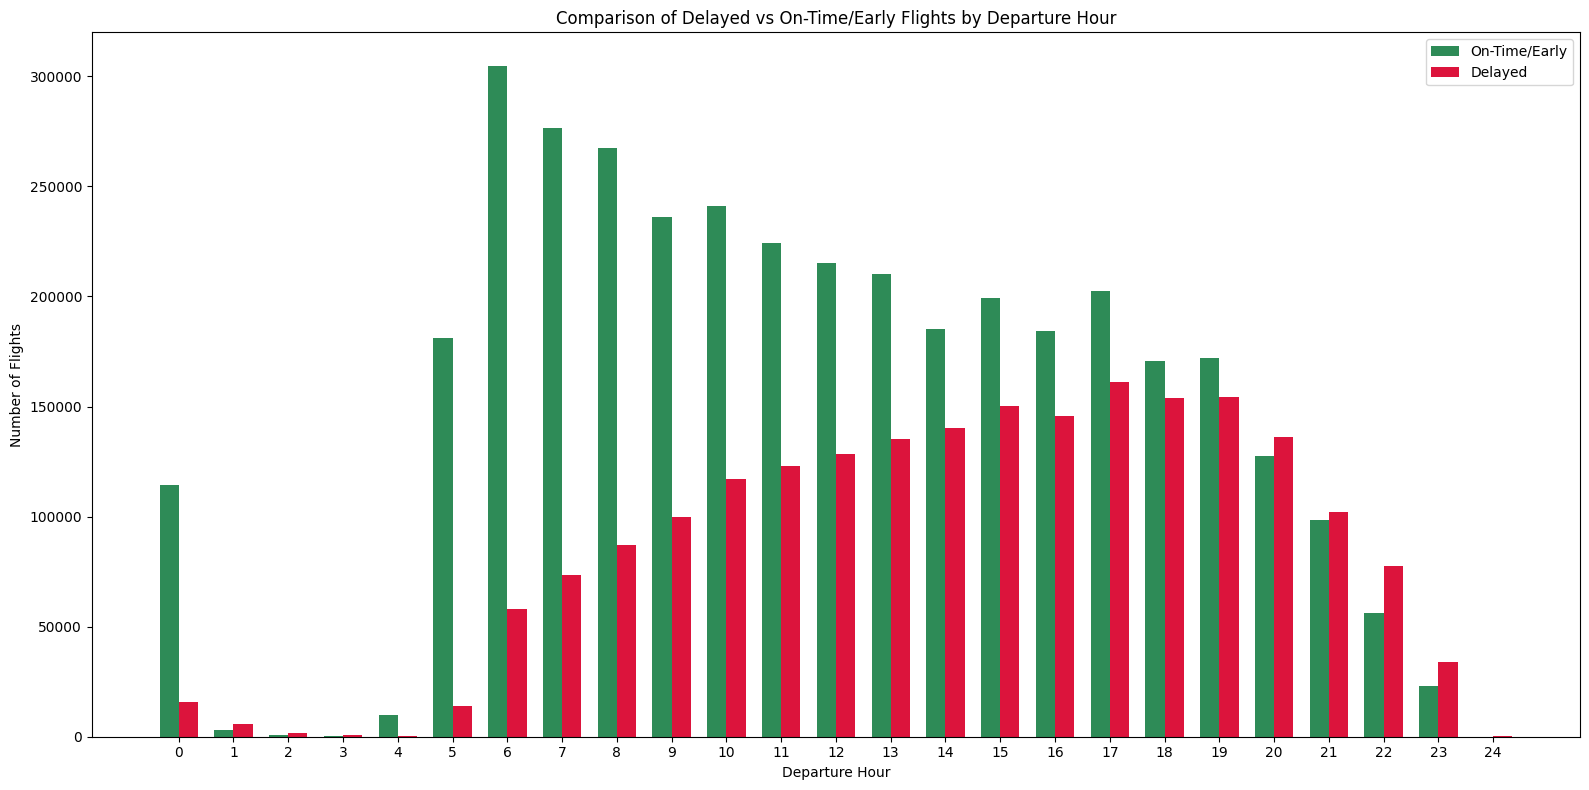

In [93]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a flag for delayed flights
flights['DELAYED'] = flights['DEPARTURE_DELAY'] > 0

# Group by departure hour
hourly_delay = flights.groupby('DEPARTURE_HOUR')['DELAYED'].value_counts().unstack().fillna(0)
hourly_delay.columns = ['On-Time/Early', 'Delayed']

# Plot grouped bar chart
plt.figure(figsize=(16,8))

x = hourly_delay.index
width = 0.35  

plt.bar(x - width/2, hourly_delay['On-Time/Early'], width=width, label='On-Time/Early', color='seagreen')
plt.bar(x + width/2, hourly_delay['Delayed'], width=width, label='Delayed', color='crimson')

plt.title("Comparison of Delayed vs On-Time/Early Flights by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


### BIVARIATE ANALYSIS

### 1.Airline vs Average Arrival Delay (Bar Plot)

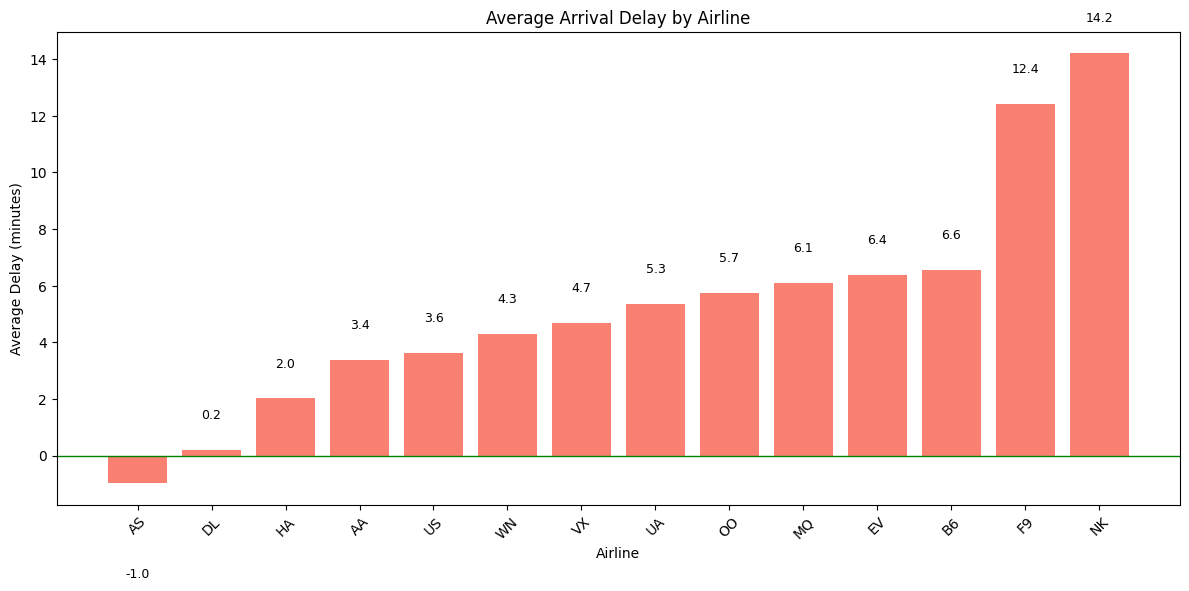

In [94]:
#1. Airline vs Average Arrival Delay (Bar Plot)
# Calculate average arrival delay per airline
avg_delay = flights.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

plt.figure(figsize=(12,6))

# Bar chart
plt.bar(avg_delay.index, avg_delay.values, color='salmon')

# Horizontal line at 0 → separates early arrivals from delays
plt.axhline(0, color='green', linewidth=1)

# Title and labeling
plt.title('Average Arrival Delay by Airline')
plt.ylabel('Average Delay (minutes)')
plt.xlabel('Airline')

# Add value labels above/below bars
for i, value in enumerate(avg_delay.values):
    plt.text(i, value + (1 if value >= 0 else -3), 
             f"{value:.1f}", 
             ha='center', 
             va='bottom' if value >= 0 else 'top',
             fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Airline performance varies significantly, with AS achieving the best punctuality and even early arrivals on average. Most major carriers maintain modest delays of 3–7 minutes, showing stable operational efficiency. NK and F9 stand out with the highest delays, indicating more frequent late arrivals compared to the rest of the industry.

### 2. Month vs Average Delay

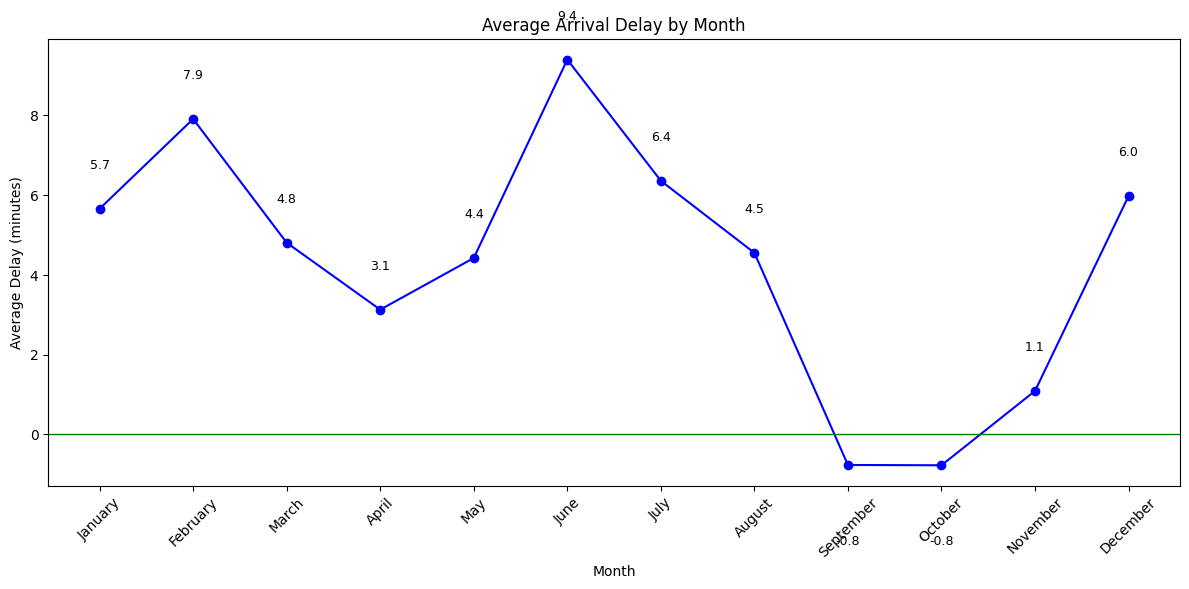

In [95]:
#2. Month vs Average Delay (Line Plot)
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

# Average arrival delay in correct month order
avg_delay_month = flights.groupby('MONTH_NAME')['ARRIVAL_DELAY'].mean().loc[order]

plt.figure(figsize=(12,6))

# Line plot with markers
plt.plot(order, avg_delay_month.values, marker='o', color='blue')

# Reference line at 0 (delay vs early arrival border)
plt.axhline(0, color='green', linewidth=1)

# Titles and labels
plt.title('Average Arrival Delay by Month')
plt.ylabel('Average Delay (minutes)')
plt.xlabel('Month')

# Add value labels above or below the points
for i, value in enumerate(avg_delay_month.values):
    offset = 1 if value >= 0 else -2
    plt.text(i, value + offset, f"{value:.1f}", ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


* Arrival delays show strong seasonality, peaking in June and February while dropping sharply in early fall. September and October even record slightly early arrivals, indicating smoother operations during these months. Overall, summer and late-winter months tend to experience the highest delays compared to the rest of the year.

### 3. Departure Hour vs Average Delay (Line Plot)

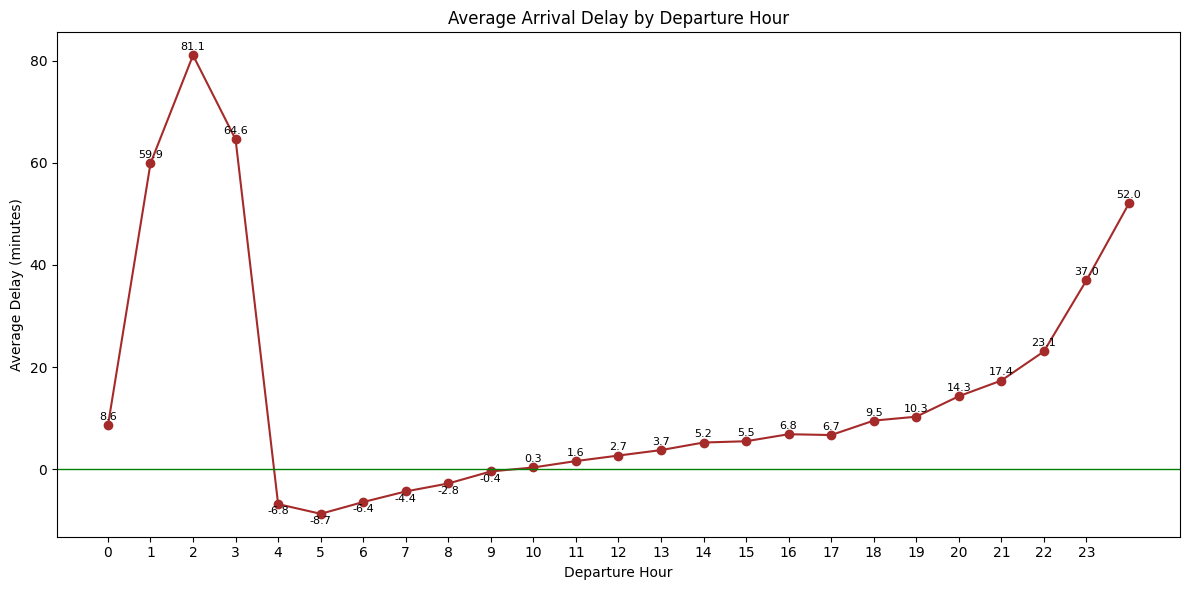

In [96]:
#3. Departure Hour vs Average Delay (Line Plot)
# Average arrival delay for each departure hour (0–23)
avg_delay_hour = flights.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean().sort_index()

plt.figure(figsize=(12,6))

# Line plot
plt.plot(avg_delay_hour.index, avg_delay_hour.values, marker='o', color='brown')

# Zero reference line
plt.axhline(0, color='green', linewidth=1)

# Titles and labels
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Delay (minutes)')

# Add value labels above/below each point
for i, value in enumerate(avg_delay_hour.values):
    offset = 1 if value >= 0 else -2
    plt.text(avg_delay_hour.index[i], value + offset, f"{value:.1f}", 
             ha='center', fontsize=8)

plt.xticks(range(24))
plt.tight_layout()
plt.show()

* Flights departing between midnight and 3 AM experience extremely high delays, indicating heavy overnight congestion or recovery from prior-day disruptions. Early-morning departures (4–7 AM) tend to arrive early, showing the clean slate effect at the start of the day. Delays gradually build up through the afternoon and spike again late at night, reflecting accumulated operational slowdowns toward the end of the day.

### 4. Distance vs Arrival Delay 

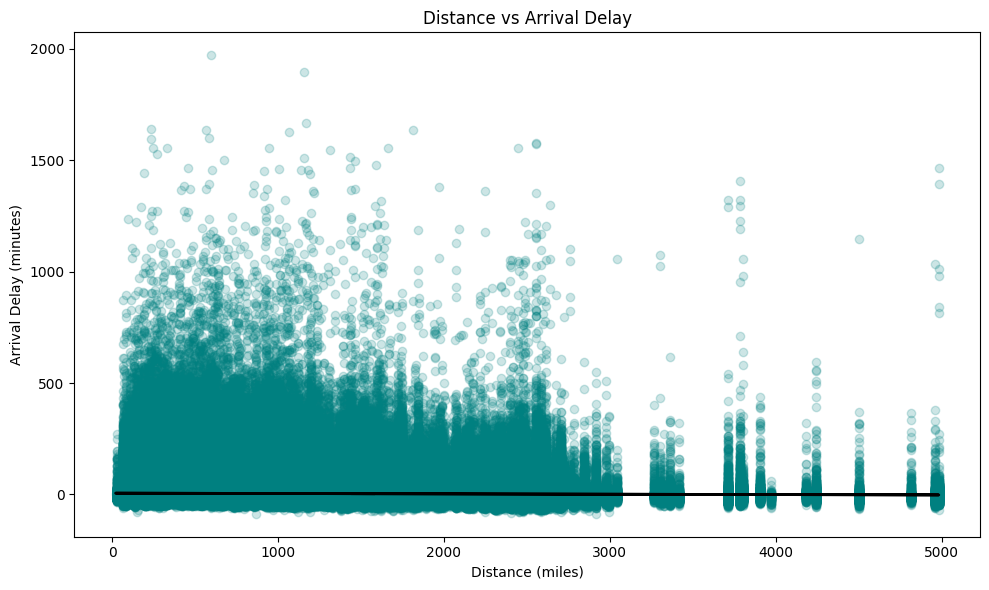

In [97]:
#10. Distance vs Arrival Delay (Scatter Plot)
# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(flights['DISTANCE'], flights['ARRIVAL_DELAY'], alpha=0.2, color='teal')

# Trend line (using basic polyfit for a simple linear trend)
x = flights['DISTANCE']
y = flights['ARRIVAL_DELAY']

coeffs = np.polyfit(x, y, 1)       # slope & intercept
trend_y = coeffs[0] * x + coeffs[1]

plt.plot(x, trend_y, color='black', linewidth=2)  # trend line

# Labels and title
plt.title('Distance vs Arrival Delay')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')

plt.tight_layout()
plt.show()

* There is no strong relationship between flight distance and arrival delay, as delays remain widely scattered across all distance ranges. Most severe delays appear on short- and medium-haul routes, suggesting operational or scheduling issues rather than distance-driven delays. Long-haul flights show fewer extreme delays, indicating more stable performance over extended routes.

### 5. Route vs Delay (Boxplot for major routes only)

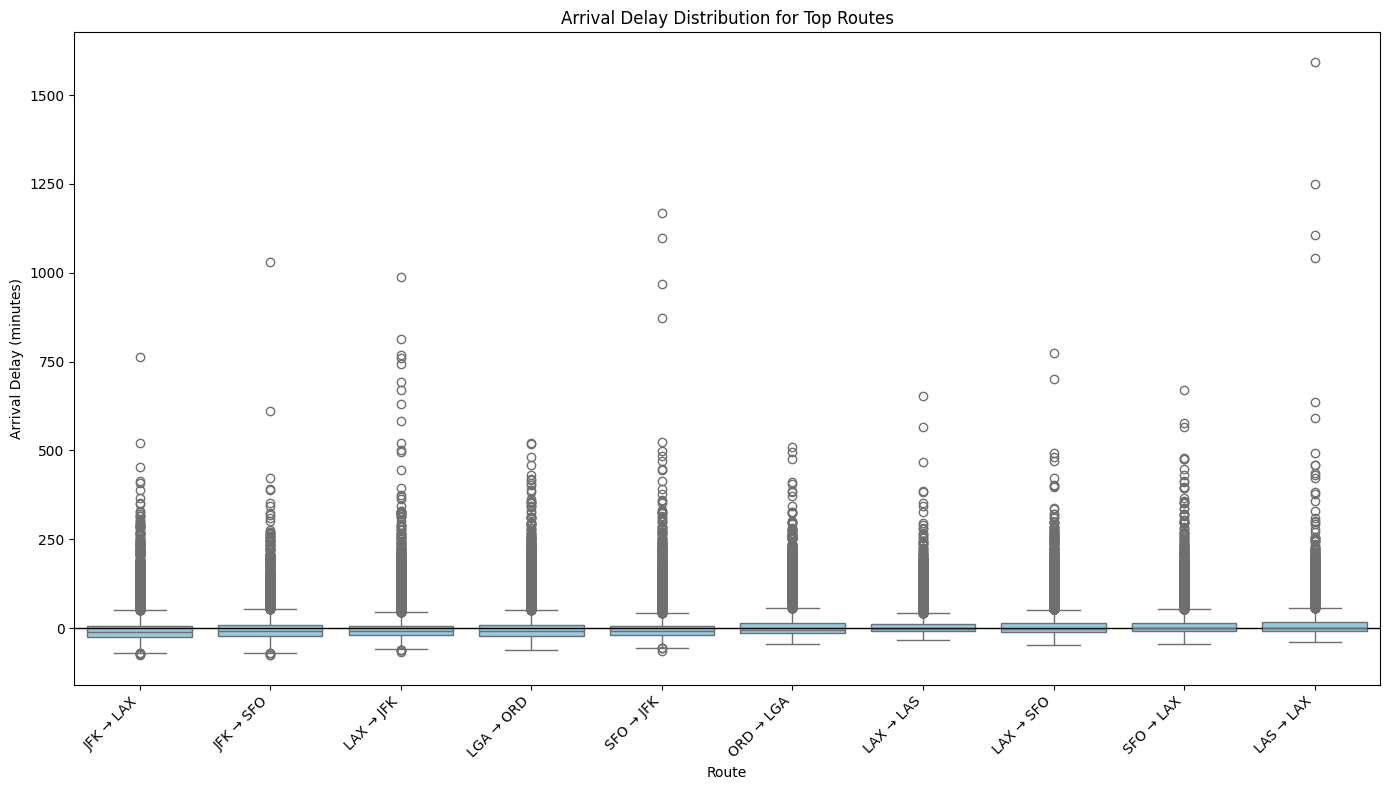

In [98]:
#11. Route vs Delay (Boxplot for major routes only)
import seaborn as sns

# Select top 10 busiest routes
major_routes = flights['ROUTE'].value_counts().head(10).index

# Filter data
subset = flights[flights['ROUTE'].isin(major_routes)]

# Sort the routes in the boxplot by median delay (more insight)
route_order = subset.groupby('ROUTE')['ARRIVAL_DELAY'].median().sort_values().index

plt.figure(figsize=(14,8))

# Boxplot
sns.boxplot(
    x='ROUTE',
    y='ARRIVAL_DELAY',
    data=subset,
    order=route_order,
    color='skyblue'
)

# Reference line to separate early arrivals (<0) from delays (>0)
plt.axhline(0, color='black', linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.title('Arrival Delay Distribution for Top Routes')
plt.ylabel('Arrival Delay (minutes)')
plt.xlabel('Route')

plt.tight_layout()
plt.show()

* Across the top routes, median arrival delays remain low and fairly consistent, but all routes exhibit a long tail of extreme delay outliers. High-traffic corridors like LAX→JFK and SFO→JFK show some of the widest spread, indicating greater vulnerability to severe disruptions. Overall, variability in delay is driven more by occasional operational spikes than by route-specific performance.

### Chart 1 — Average Arrival Delay by Airline (bar with 0-line)

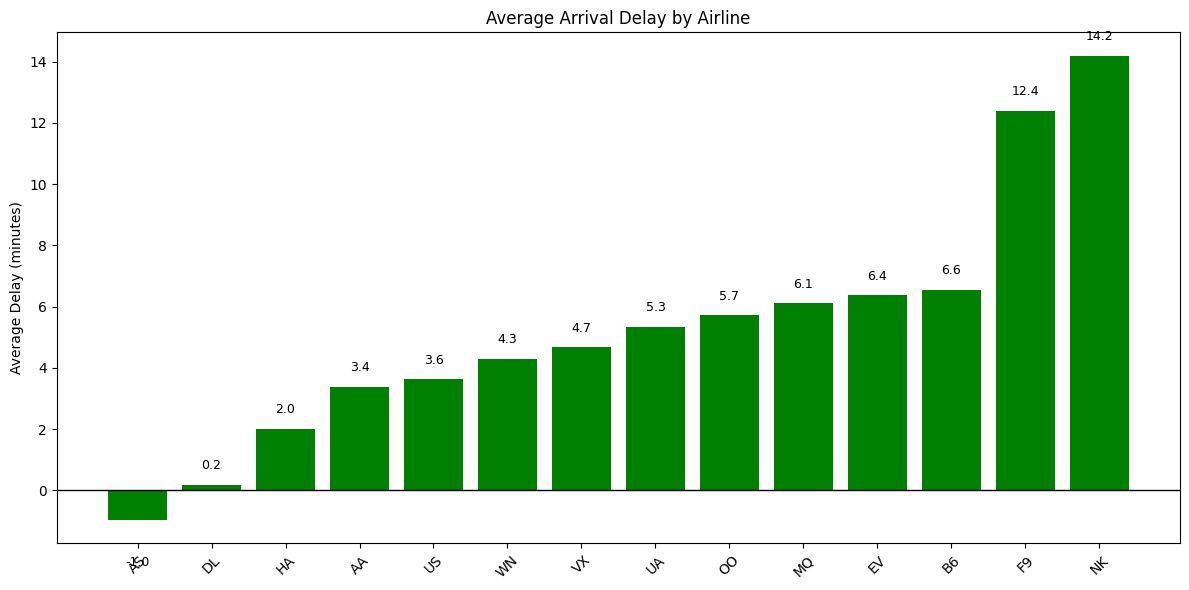

In [99]:
#Chart 1 — Average Arrival Delay by Airline (bar with 0-line)

avg_delay_airline = flights.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

plt.figure(figsize=(12,6))
plt.bar(avg_delay_airline.index, avg_delay_airline.values, color='green')
plt.axhline(0, color='k', linewidth=1)
plt.xticks(rotation=45)
plt.title('Average Arrival Delay by Airline')
plt.ylabel('Average Delay (minutes)')
for i, v in enumerate(avg_delay_airline.values):
    plt.text(i, v + (0.5 if v>=0 else -1.5), f"{v:.1f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Explanation: Identifies which carriers are on average late or early — a quick way to spot top delay-prone carriers for further cause analysis.

### Chart 2 — Delay Cause Breakdown by Airline (stacked bar)

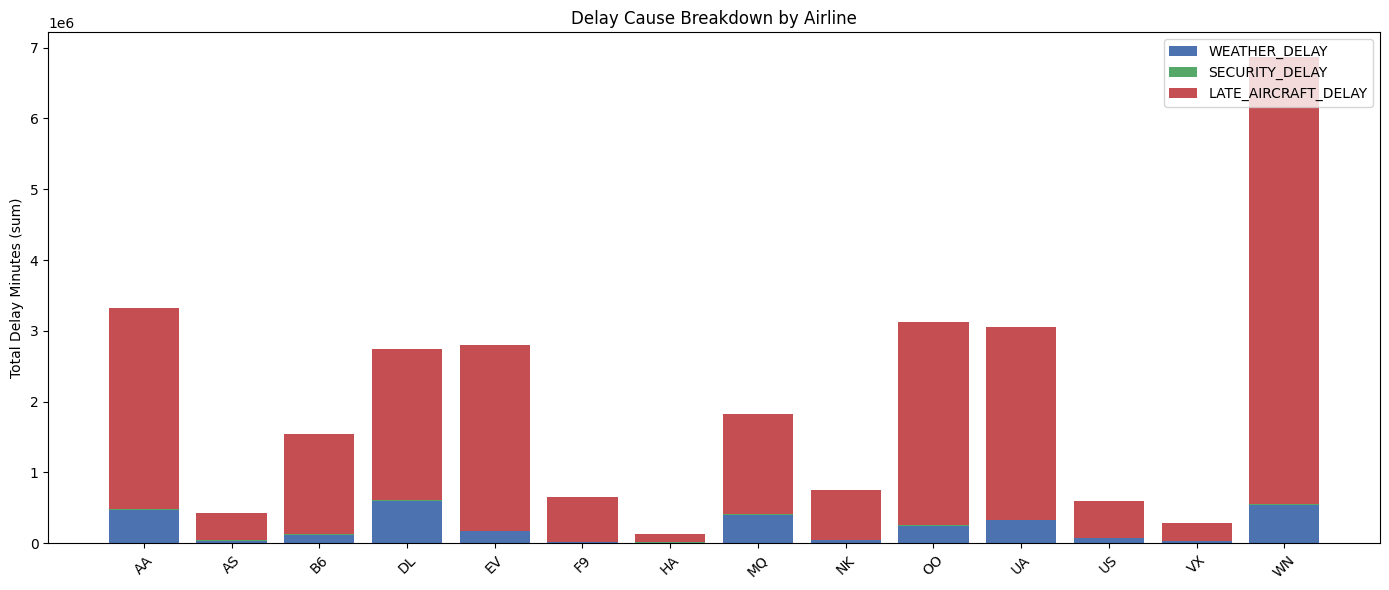

In [100]:
#Chart 2 — Delay Cause Breakdown by Airline (stacked bar)

# Sum delays by cause per airline
cause_cols = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
# fill missing delay-cause columns gracefully
present = [c for c in cause_cols if c in flights.columns]
delay_sum = flights.groupby('AIRLINE')[present].sum()

plt.figure(figsize=(14,6))
delay_sum_norm = delay_sum  # raw sums (stacked)
bottom = None
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974'][:len(present)]
for idx, c in enumerate(present):
    if idx==0:
        p = plt.bar(delay_sum.index, delay_sum[c], color=colors[idx], label=c)
        bottom = delay_sum[c].copy()
    else:
        plt.bar(delay_sum.index, delay_sum[c], bottom=bottom, color=colors[idx], label=c)
        bottom = bottom + delay_sum[c]

plt.xticks(rotation=45)
plt.ylabel('Total Delay Minutes (sum)')
plt.title('Delay Cause Breakdown by Airline')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Explanation: Shows which delay types dominate per carrier (carrier vs weather vs NAS etc.), helping prioritize interventions by airline.

In [101]:
flights.columns

Index(['YEAR', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE', 'MONTH_NAME',
       'DAY_NAME', 'SEASON', 'WEEK', 'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR',
       'IS_WEEKEND', 'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET',
       'IS_RED_EYE', 'FLIGHT_SPEED', 'DELAYED'],
      dtype='object')

### Chart 3 — Delay by Time of Day (hour) — total average arrival delay

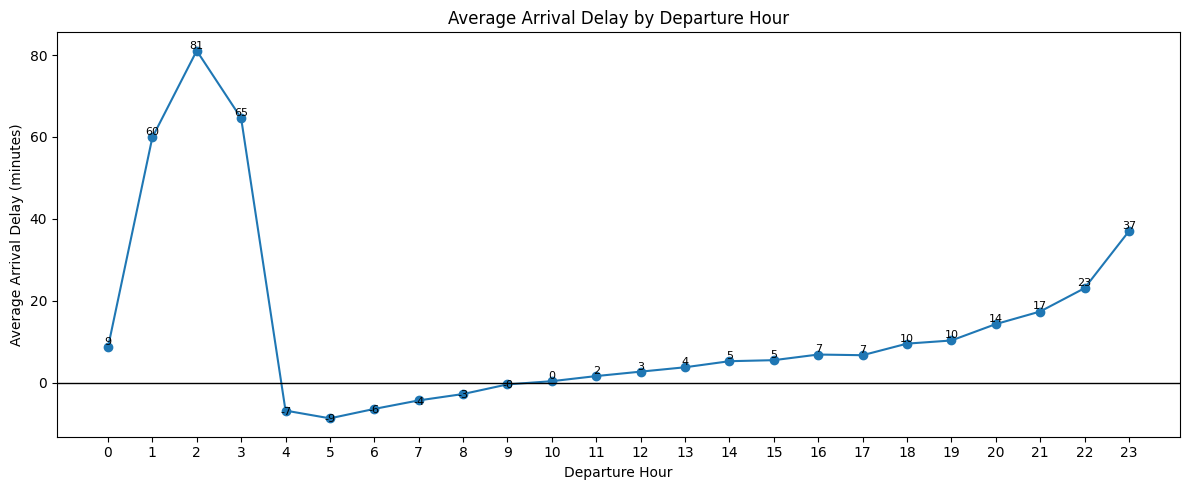

In [102]:
#Chart 3 — Delay by Time of Day (hour) — total average arrival delay
hour_avg = flights.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean().reindex(range(24), fill_value=0)

plt.figure(figsize=(12,5))
plt.plot(hour_avg.index, hour_avg.values, marker='o')
plt.axhline(0, color='k', linewidth=1)
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(range(0,24,1))
for h, val in hour_avg.items():
    plt.text(h, val + (0.5 if val>=0 else -1.0), f"{val:.0f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

Explanation: Reveals peak hours for delays (e.g., late-night spikes) and helps schedule-level mitigation planning.

### Chart 4 — Weather Delay vs Arrival Delay (scatter + small trend)

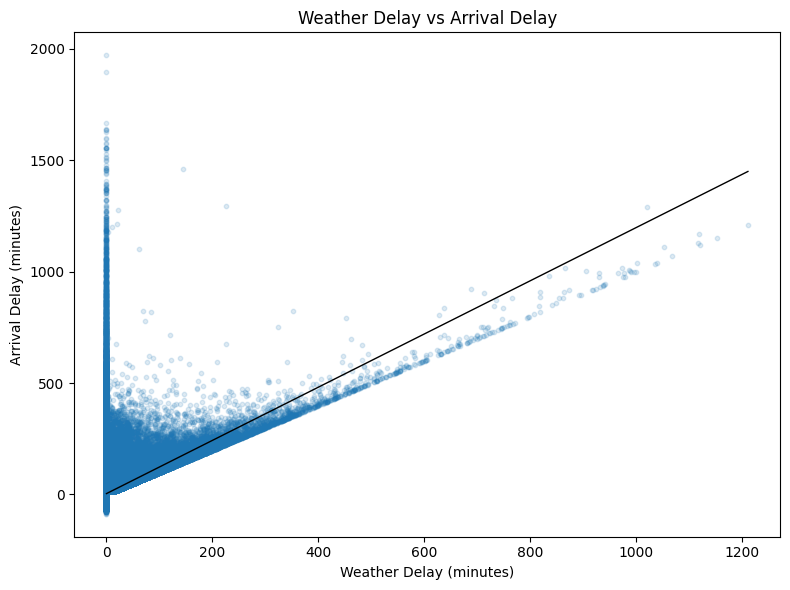

In [103]:
#Chart 4 — Weather Delay vs Arrival Delay (scatter + small trend)

plt.figure(figsize=(8,6))
x = flights['WEATHER_DELAY'].fillna(0)
y = flights['ARRIVAL_DELAY'].fillna(0)
plt.scatter(x, y, alpha=0.15, s=10)
# simple linear trend
import numpy as np
mask = (~x.isna()) & (~y.isna())
if mask.sum() > 10:
    m, b = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b, color='black', linewidth=1)
plt.xlabel('Weather Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.title('Weather Delay vs Arrival Delay')
plt.tight_layout()
plt.show()



Explanation: Checks how strongly weather delay contributes to final arrival delay — useful to quantify weather impact.

### Chart 5 — Carrier Delay Trend Through the Day (top carriers)

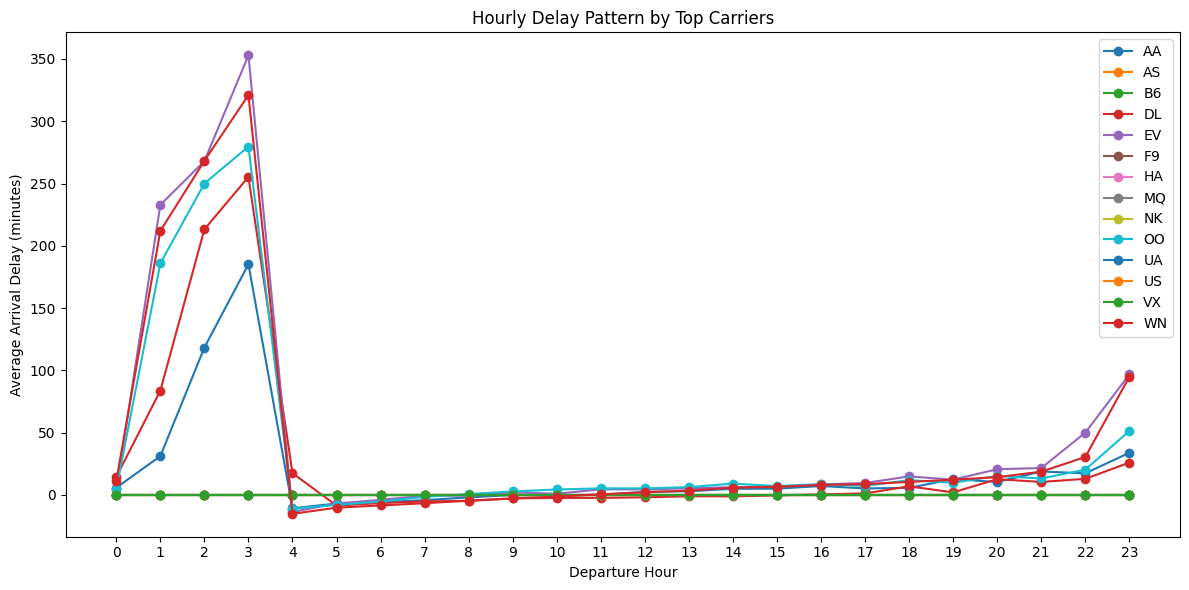

In [104]:
#Chart 5 — Carrier Delay Trend Through the Day (top carriers)
# pick top 5 carriers by flight count
top_carriers = flights['AIRLINE'].value_counts().head(5).index
carrier_hour = flights[flights['AIRLINE'].isin(top_carriers)].groupby(['AIRLINE','DEPARTURE_HOUR'])['ARRIVAL_DELAY'].mean().unstack(0).reindex(range(24)).fillna(0)

plt.figure(figsize=(12,6))
for c in carrier_hour.columns:
    plt.plot(carrier_hour.index, carrier_hour[c], marker='o', label=c)
plt.xlabel('Departure Hour')
plt.ylabel('Average Arrival Delay (minutes)')
plt.title('Hourly Delay Pattern by Top Carriers')
plt.xticks(range(0,24))
plt.legend()
plt.tight_layout()
plt.show()

Explanation: Compares how top carriers accumulate delays across the day — reveals which carriers struggle at specific times.

### Chart 6 — Airport × Hour Heatmap of Average Delay

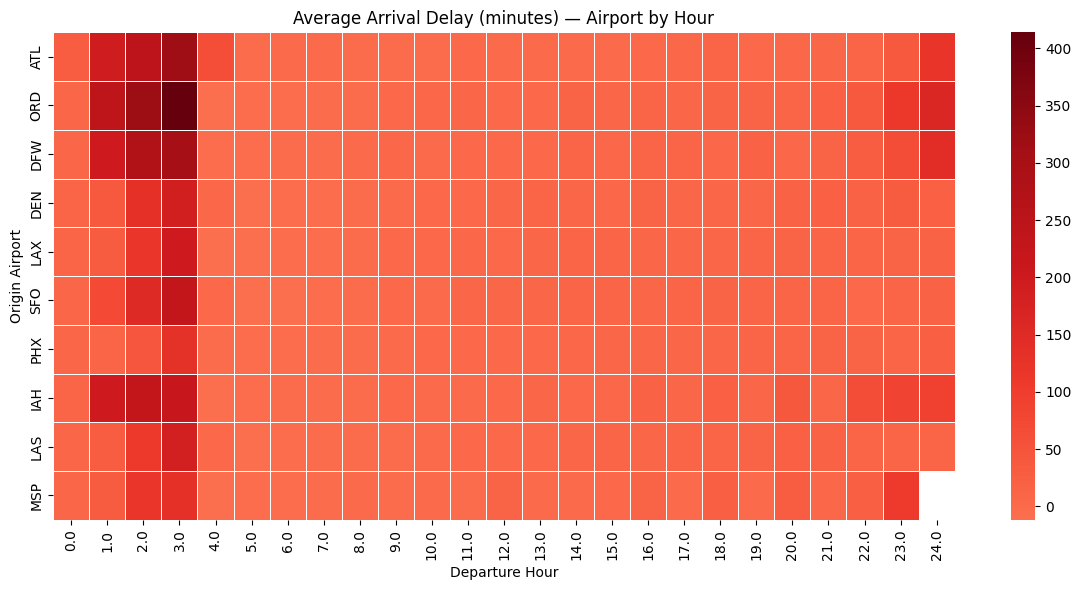

In [105]:
#Chart 6 — Airport × Hour Heatmap of Average Delay
# choose a set of busiest airports
busiest = flights['ORIGIN_AIRPORT'].value_counts().head(10).index
pivot = flights[flights['ORIGIN_AIRPORT'].isin(busiest)].groupby(['ORIGIN_AIRPORT','DEPARTURE_HOUR'])['ARRIVAL_DELAY'].mean().unstack(1).reindex(busiest)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='Reds', center=0, linewidths=0.5, linecolor='white')
plt.title('Average Arrival Delay (minutes) — Airport by Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.show()

Explanation: Identifies airports and hours with concentrated delay problems — useful for targeted operational fixes.

### Chart 7 — Boxplot of Total Delay for Top Routes (to check route-level variability)

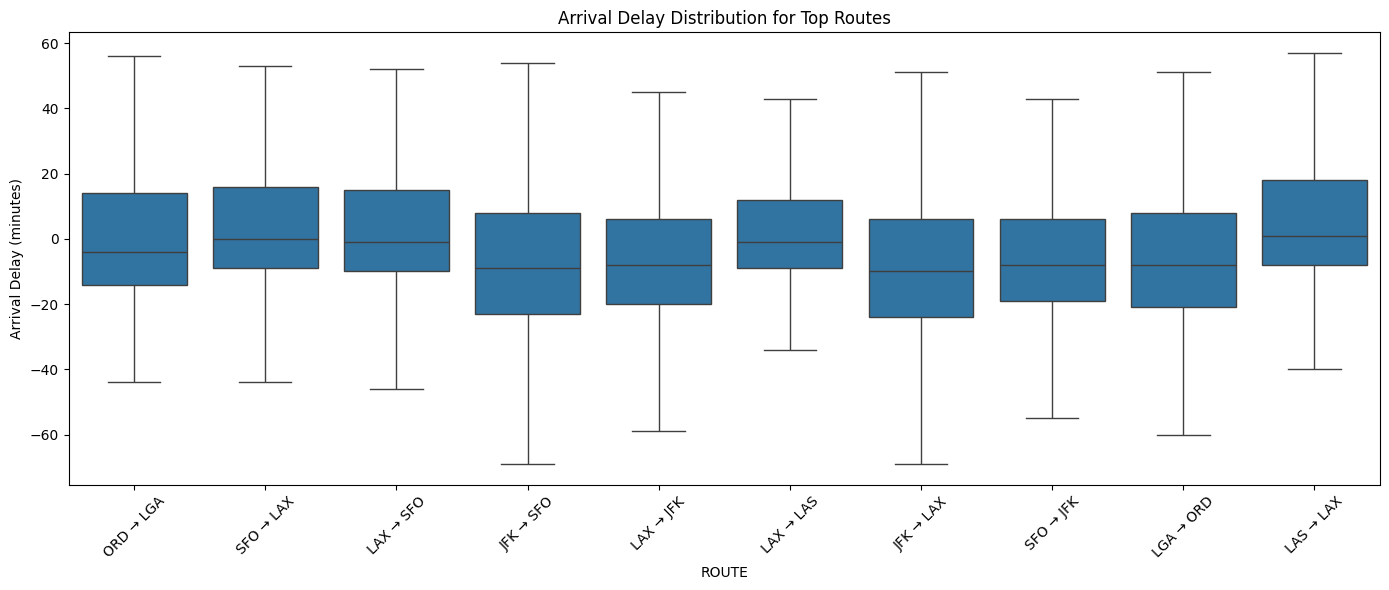

In [106]:
#Chart 7 — Boxplot of Total Delay for Top Routes (to check route-level variability)
top_routes = flights['ROUTE'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.boxplot(x='ROUTE', y='ARRIVAL_DELAY', data=flights[flights['ROUTE'].isin(top_routes)], showfliers=False)
plt.xticks(rotation=45)
plt.title('Arrival Delay Distribution for Top Routes')
plt.ylabel('Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

Explanation: Compares route-level variability in delays, showing which routes have frequent severe disruptions vs consistent performance.

### Chart 8 — Correlation Matrix of Delay Causes (quick check of relationships)

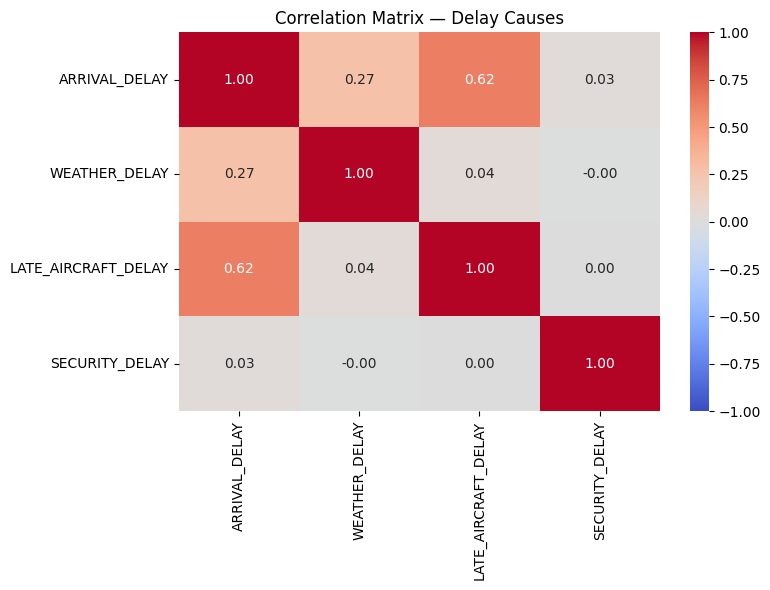

In [107]:
#Chart 8 — Correlation Matrix of Delay Causes (quick check of relationships)
present = [c for c in ['ARRIVAL_DELAY','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','LATE_AIRCRAFT_DELAY','SECURITY_DELAY'] if c in flights.columns]
corr = flights[present].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Delay Causes')
plt.tight_layout()
plt.show()

Explanation: Shows which delay causes are correlated with arrival delay and with each other — helps prioritize cause-specific models.

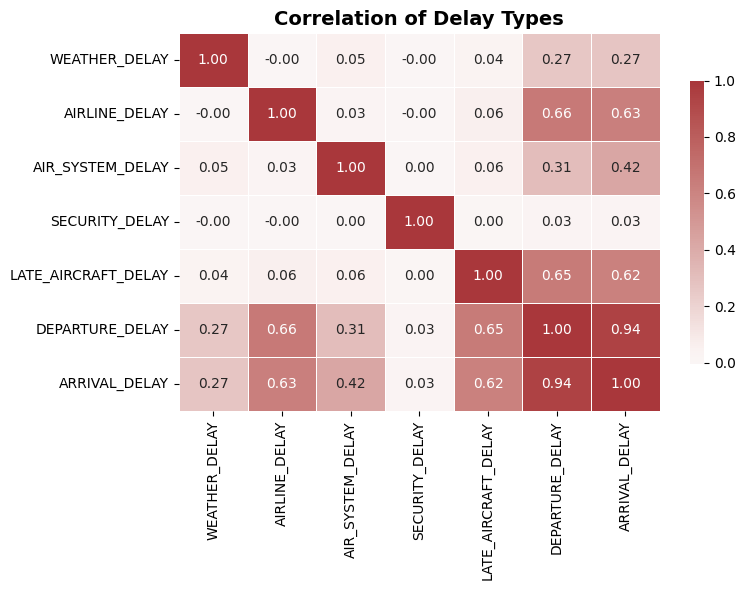

In [140]:
import seaborn as sns
# ---- CONFIG ----
delay_candidates = [
    'WEATHER_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY'
]
title = "Correlation of Delay Types"
figsize = (8,6)

# ---- PREP ----
df = flights.copy()
# ensure numeric
for c in delay_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
# select only present columns
present = [c for c in delay_candidates if c in df.columns]
if len(present) < 2:
    raise ValueError(f"Not enough delay columns found. Found: {present}")

corr = df[present].corr(method='pearson')

# ---- PLOT ----
plt.figure(figsize=figsize)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="vlag", center=0,
    linewidths=.5, cbar_kws={'shrink': .75}
)
plt.title(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Key Insights**

* **Departure delay and arrival delay are highly correlated (0.94)** — meaning once a flight is delayed at departure, it almost always arrives late.
* **Airline delay and late-aircraft delay show strong correlation with both departure and arrival delays (0.63–0.66)**, indicating airline-related issues are major contributors to overall delays.
* **Weather delay has only a mild correlation (~0.27)** with departure and arrival delays, suggesting weather is not the dominant delay driver in this dataset.
* **Air system delay (ATC delays) has moderate correlation with arrival delay (0.42)** — showing some influence from air traffic congestion.
* **Security delays show almost no correlation** with any other delay type, meaning they are rare and isolated events.

-----------------------------

### Milestone 3: Route, Cancellation, and Seasonal Insights 

Week 5: Route and Airport-Level Analysis 

• Top 10 origin-destination pairs 

• Delay heatmaps by airport and route 

• Maps showing busiest airports and average delays 

Week 6: Seasonal and Cancellation Analysis 

• Monthly cancellation trends 

• Cancellation types: carrier, weather, security, NAS 

• Analyze impact of holidays or winter months 

Deliverables: 

• Seasonal visual summaries 

• Insights on route congestion and cancellations


### CHART 1 — Top 10 Origin–Destination Routes

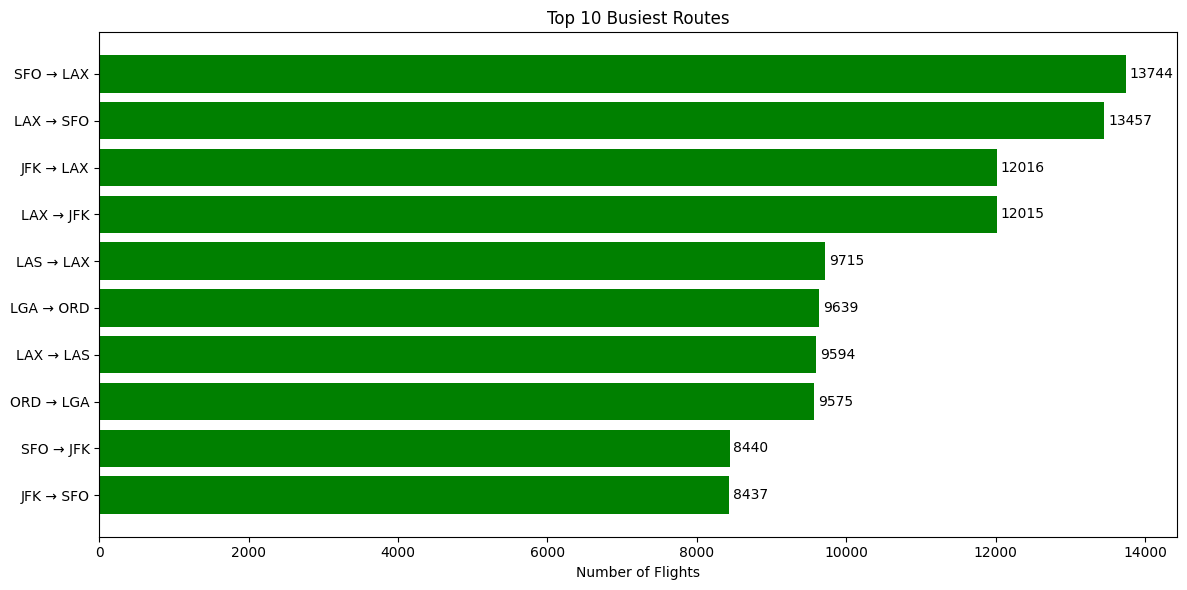

In [108]:
# Correct: Get top 10 busiest routes with their counts
top_routes = flights['ROUTE'].value_counts().head(10)

plt.figure(figsize=(12, 6))

# Plot
plt.barh(top_routes.index, top_routes.values, color='green')
plt.gca().invert_yaxis()

plt.title('Top 10 Busiest Routes')
plt.xlabel('Number of Flights')

# Add labels on bars
for i, v in enumerate(top_routes.values):
    plt.text(v + 50, i, str(v), va='center')

plt.tight_layout()
plt.show()


### Explanation for Report

These are the most frequently traveled city pairs in the dataset. High-volume routes indicate heavy demand and potential congestion spots for analysis.

### CHART 2 — Heatmap of Average Delay by Airport and Hour

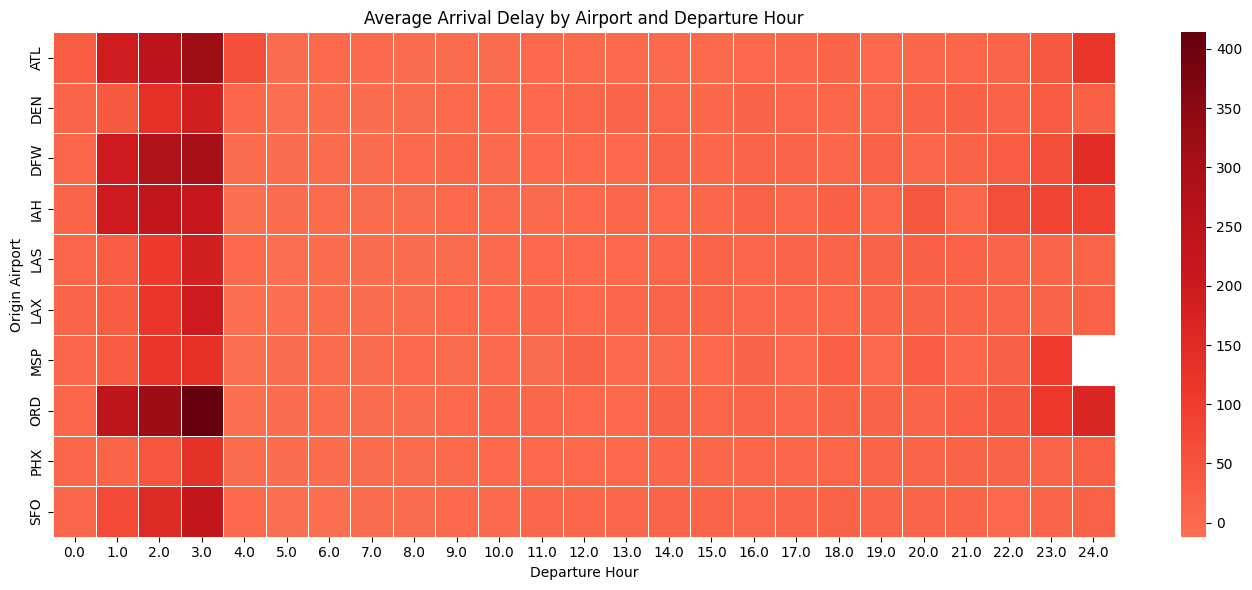

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
top_airports = flights['ORIGIN_AIRPORT'].value_counts().head(10).index

airport_delay = (
    flights[flights['ORIGIN_AIRPORT'].isin(top_airports)]
    .pivot_table(
        values='ARRIVAL_DELAY',
        index='ORIGIN_AIRPORT',
        columns='DEPARTURE_HOUR',
        aggfunc='mean'
    )
)

plt.figure(figsize=(14,6))
sns.heatmap(airport_delay, cmap="Reds", center=0, linewidths=.5)
plt.title("Average Arrival Delay by Airport and Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Origin Airport")
plt.tight_layout()
plt.show()
#CHART 3 — Heatmap of Average Delay by Airport and Hour

* This heatmap highlights how delays vary across different hours at major airports. Peak delay periods usually occur in the afternoon and evening, indicating congestion and propagated delays across busy hubs

### CHART 3-Delay Heatmap by Route (Route × Hour)

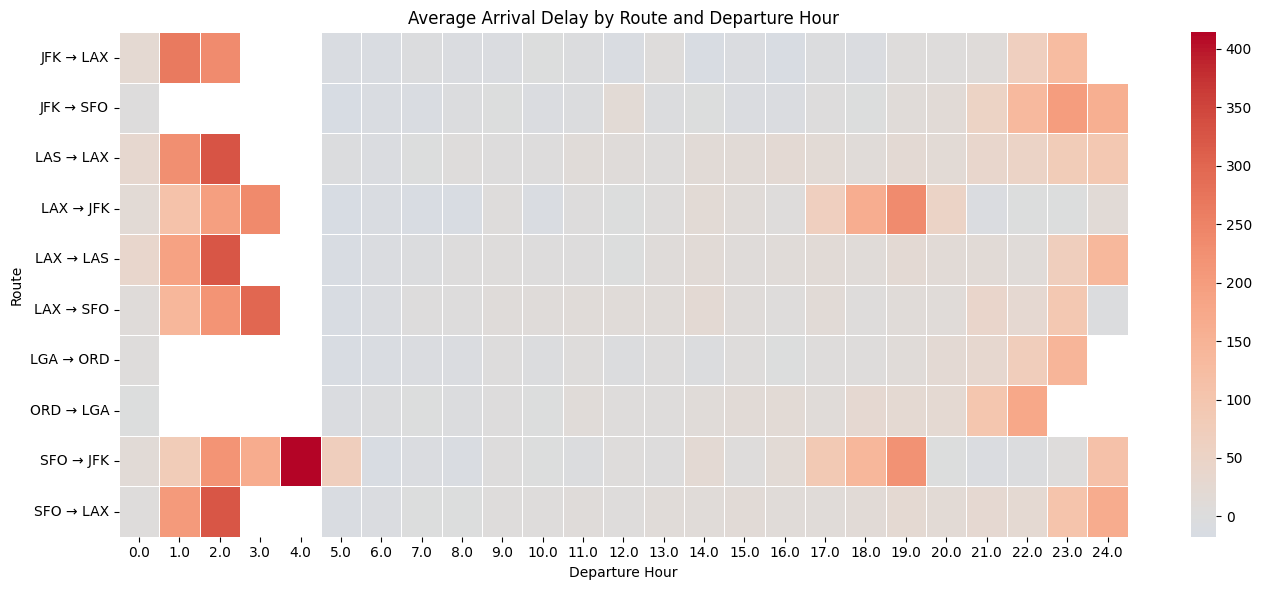

In [110]:
#Delay Heatmap by Route (Route × Hour)

top_routes = flights['ROUTE'].value_counts().head(10).index

route_delay = (
    flights[flights['ROUTE'].isin(top_routes)]
    .pivot_table(
        values='ARRIVAL_DELAY',
        index='ROUTE',
        columns='DEPARTURE_HOUR',
        aggfunc='mean'
    )
)

plt.figure(figsize=(14,6))
sns.heatmap(route_delay, cmap="coolwarm", center=0, linewidths=.5)
plt.title("Average Arrival Delay by Route and Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Route")
plt.tight_layout()
plt.show()


In [111]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')

In [112]:
flights.columns

Index(['YEAR', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE', 'MONTH_NAME',
       'DAY_NAME', 'SEASON', 'WEEK', 'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR',
       'IS_WEEKEND', 'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET',
       'IS_RED_EYE', 'FLIGHT_SPEED', 'DELAYED'],
      dtype='object')

### 1. Interactive World Map: Busiest Airports (Top 50)

In [113]:
import folium
from IPython.display import display

# ------------------------------
# 1) BUSIEST AIRPORTS MAP
# ------------------------------

# Count departures and arrivals
dep = flights.groupby('ORIGIN_AIRPORT').size().reset_index(name='DEP')
arr = flights.groupby('DESTINATION_AIRPORT').size().reset_index(name='ARR')

dep = dep.rename(columns={'ORIGIN_AIRPORT':'IATA_CODE'})
arr = arr.rename(columns={'DESTINATION_AIRPORT':'IATA_CODE'})

traffic = dep.merge(arr, on='IATA_CODE', how='outer').fillna(0)
traffic['TOTAL'] = traffic['DEP'] + traffic['ARR']

# Merge with airport coordinates
air = airports.copy()
air['IATA_CODE'] = air['IATA_CODE'].astype(str).str.strip()
traffic['IATA_CODE'] = traffic['IATA_CODE'].astype(str).str.strip()

busiest = traffic.merge(air, on='IATA_CODE', how='left')
busiest = busiest.dropna(subset=['LATITUDE', 'LONGITUDE'])

# 🔥 Select only TOP 50 busiest airports
busiest = busiest.sort_values('TOTAL', ascending=False).head(50)

# Create map
busiest_map = folium.Map(location=[20,0], zoom_start=2, tiles="CartoDB positron")

for _, row in busiest.iterrows():
    radius = 1 + np.log1p(row['TOTAL']) * 3
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=(
            f"<b>Airport:</b> {row['AIRPORT']}<br>"
            f"<b>City:</b> {row['CITY']}<br>"
            f"<b>Total Flights:</b> {int(row['TOTAL'])}"
        )
    ).add_to(busiest_map)

# Show inline
display(busiest_map)

### 2. Interactive Map: Airports by Average Delay

In [114]:
# 2) AVERAGE DELAY MAP
# ------------------------------

fl = flights.copy()
fl['DEPARTURE_DELAY'] = pd.to_numeric(fl['DEPARTURE_DELAY'], errors='coerce')
fl = fl.dropna(subset=['ORIGIN_AIRPORT','DEPARTURE_DELAY'])

avg_delay = fl.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()
avg_delay = avg_delay.rename(columns={'ORIGIN_AIRPORT':'IATA_CODE',
                                      'DEPARTURE_DELAY':'AVG_DELAY'})

avg_delay['IATA_CODE'] = avg_delay['IATA_CODE'].astype(str).str.strip()

delay_data = avg_delay.merge(air, on='IATA_CODE', how='left')
delay_data = delay_data.dropna(subset=['LATITUDE','LONGITUDE'])

def delay_color(d):
    if d < 0: return "green"
    elif d < 10: return "yellow"
    elif d < 20: return "orange"
    else: return "red"

delay_map = folium.Map(location=[20,0], zoom_start=2, tiles="CartoDB dark_matter")

for _, row in delay_data.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=5,
        color=delay_color(row['AVG_DELAY']),
        fill=True,
        fill_opacity=0.8,
        popup=(
            f"<b>Airport:</b> {row['AIRPORT']}<br>"
            f"<b>City:</b> {row['CITY']}<br>"
            f"<b>Avg Delay:</b> {row['AVG_DELAY']:.2f} min"
        )
    ).add_to(delay_map)

display(delay_map)

### WEEK 6: Seasonal & Cancellation Analysis

#### 1. Monthly Cancellation Trends

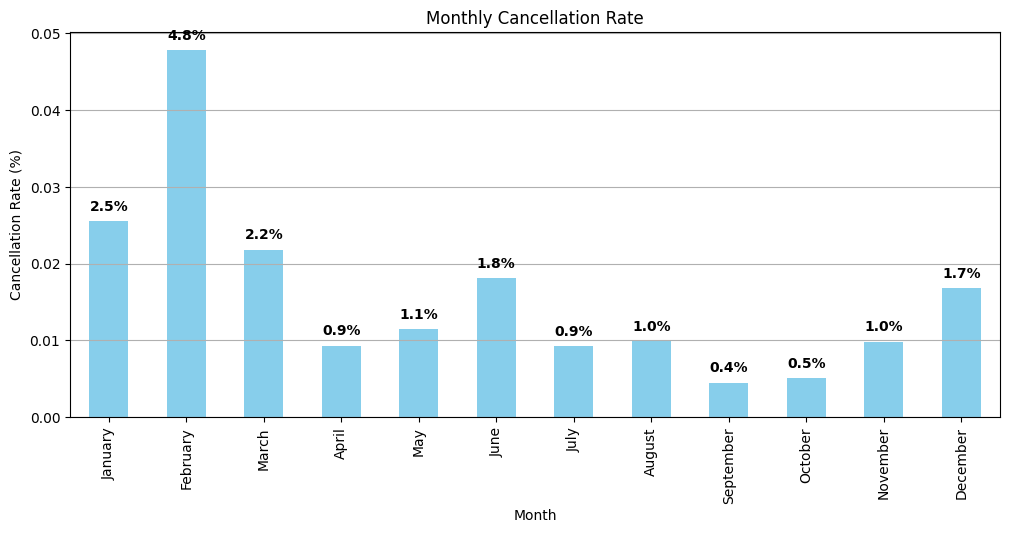

In [116]:
import matplotlib.pyplot as plt

# Ensure CANCELLED is numeric (0 or 1)
flights['CANCELLED'] = pd.to_numeric(flights['CANCELLED'], errors='coerce').fillna(0)

# Calculate monthly cancellation rate
monthly_cancel = flights.groupby('MONTH_NAME')['CANCELLED'].mean().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))
ax = monthly_cancel.plot(kind='bar', color="skyblue")

plt.title("Monthly Cancellation Rate")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Month")
plt.grid(axis='y')

# Add percentage labels on bars
for i, value in enumerate(monthly_cancel):
    plt.text(i, value + 0.001, f"{value*100:.1f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

**Key Conclusions from Monthly Cancellation Rate:**

* February has the highest cancellation rate (4.8%), indicating strong operational disruption during peak winter conditions.

* January also shows elevated cancellations (2.5%), reinforcing that early winter heavily impacts flight reliability.

* December (1.7%) shows a moderate increase, likely due to winter weather combined with heavy holiday traffic.

* Spring and summer months (March to August) maintain relatively stable and low cancellation rates between 0.9% and 1.1%.

* September has the lowest cancellation rate (0.4%), suggesting minimal weather issues and lower travel congestion.

* October and November remain moderately low (0.5%–1.0%), showing continued operational stability.

* Overall trend shows that winter months cause the majority of cancellations, while the rest of the year experiences fewer disruptions.

* The seasonal pattern confirms that weather-related challenges are the dominant cause of cancellations, especially in early-year winter peaks.

### 2. Breakdown cancellation Reasons

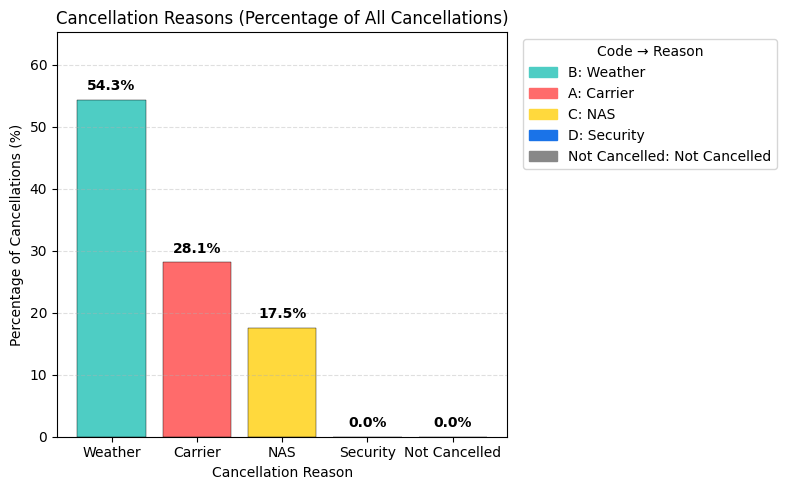

In [120]:
# Filter cancelled flights only
cancelled_flights = flights[flights['CANCELLED'] == 1].copy()

# Count cancellations by reason code (A/B/C/D)
cancel_reason_counts = cancelled_flights['CANCELLATION_REASON'].value_counts()

# Mapping full names
reason_labels_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'D': 'Security'
}

# Colors for each category (keeps consistent across charts)
colors_map = {
    'A': '#FF6B6B',   # red-ish
    'B': '#4ECDC4',   # teal
    'C': '#FFD93D',   # yellow
    'D': '#1A73E8'    # blue
}

# Ensure a stable order: use only existing codes in the data, sorted by count desc
codes = cancel_reason_counts.index.tolist()
counts = cancel_reason_counts.values
total = counts.sum()
percentages = (counts / total) * 100

# Prepare labels and colors for plotting (full names)
full_names = [reason_labels_map.get(code, code) for code in codes]
colors = [colors_map.get(code, '#888888') for code in codes]  # fallback grey if unknown code

# -------------------------
# 1) Bar chart with % labels
# -------------------------
plt.figure(figsize=(8,5))
bars = plt.bar(full_names, percentages, color=colors, edgecolor='k', linewidth=0.3)

plt.title("Cancellation Reasons (Percentage of All Cancellations)")
plt.ylabel("Percentage of Cancellations (%)")
plt.xlabel("Cancellation Reason")
plt.ylim(0, max(percentages) * 1.20)  # give some headroom for labels
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add percentage labels above bars
for i, p in enumerate(percentages):
    plt.text(i, p + (max(percentages) * 0.02), f"{p:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Optional legend showing code -> full name
legend_items = [plt.Rectangle((0,0),1,1, color=colors_map.get(c, '#888888')) for c in codes]
legend_labels = [f"{c}: {reason_labels_map.get(c, c)}" for c in codes]
plt.legend(legend_items, legend_labels, title="Code → Reason", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Here are the key insights:

* **Weather is the main reason** for cancellations, making up **over half (≈54%)** of all cancelled flights.
* **Carrier issues** are the second biggest cause, contributing about **28%**.
* **NAS delays** account for around **17%**, showing moderate impact.
* **Security-related cancellations are almost zero**, meaning they rarely disrupt operations.
* Overall, **weather and airline operational issues are the major drivers** of flight cancellations.


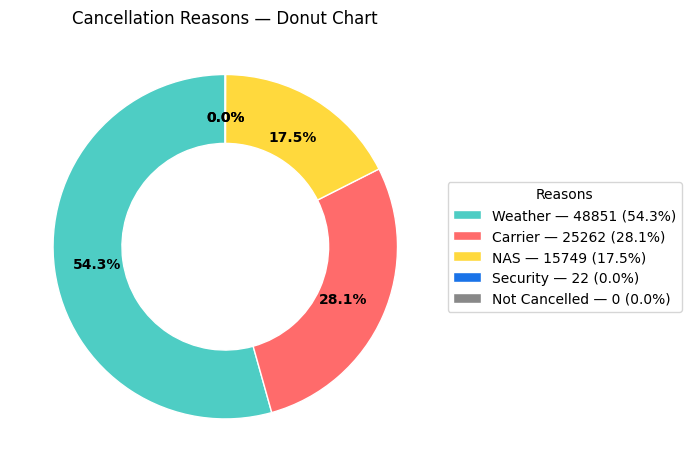

In [121]:

# -------------------------
# 2) Donut / Pie chart with % inside slices
# -------------------------
plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    counts,
    labels=None,                # we will use legend for labels to keep chart clean
    autopct=lambda pct: f"{pct:.1f}%", 
    startangle=90,
    colors=colors,
    pctdistance=0.75,           # position of the percentage text
    wedgeprops=dict(width=0.4, edgecolor='w')  # width creates donut
)

# Add center circle for donut look (alternative to wedgeprops width)
# centre_circle = plt.Circle((0,0),0.45,fc='white')
# plt.gca().add_artist(centre_circle)

plt.title("Cancellation Reasons — Donut Chart")

# Build legend with full names and counts
legend_labels = [f"{reason_labels_map.get(c,c)} — {int(cancel_reason_counts[c])} ({(cancel_reason_counts[c]/total)*100:.1f}%)" for c in codes]
plt.legend(wedges, legend_labels, title="Reasons", loc='center left', bbox_to_anchor=(1, 0.5))

# Improve contrast of autopct text
for txt in autotexts:
    txt.set_color('black')
    txt.set_fontweight('bold')

plt.tight_layout()
plt.show()

### 3. Cancellation rate by season

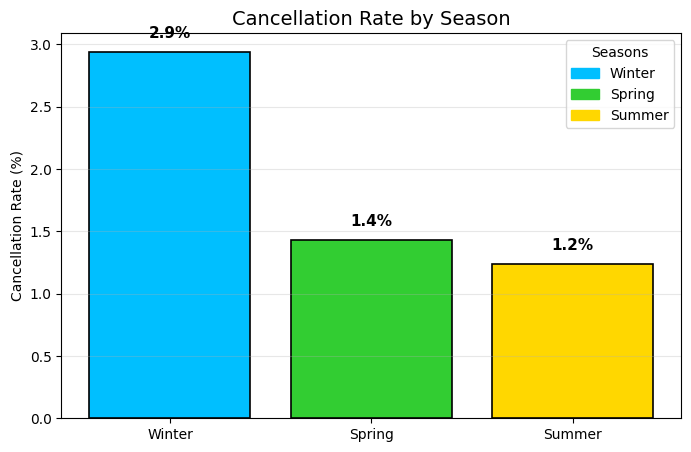

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Compute cancellation rate per season (percent out of 100)
season_cancel = flights.groupby('SEASON')['CANCELLED'].mean() * 100

# Proper order
season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_cancel = season_cancel.reindex([s for s in season_order if s in season_cancel.index])

# Bright colors
bright_colors = {
    "Winter": "#00BFFF",   # Bright blue
    "Spring": "#32CD32",   # Lime green
    "Summer": "#FFD700",   # Gold
    "Autumn": "#FF4500"    # Orange-red
}

colors = [bright_colors.get(s, "#888888") for s in season_cancel.index]

plt.figure(figsize=(8,5))
bars = plt.bar(season_cancel.index, season_cancel.values, 
               color=colors, edgecolor='black', linewidth=1.2)

plt.title("Cancellation Rate by Season", fontsize=14)
plt.ylabel("Cancellation Rate (%)")
plt.grid(axis='y', alpha=0.3)

# Percentage labels
for i, value in enumerate(season_cancel.values):
    plt.text(i, value + (max(season_cancel.values) * 0.03),
             f"{value:.1f}%", 
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Legend with bright colors
legend_patches = [plt.Rectangle((0,0),1,1, color=bright_colors[s]) 
                  for s in season_cancel.index]
plt.legend(legend_patches, season_cancel.index, title="Seasons", loc='upper right')

plt.show()


* **Winter has the highest cancellation rate (2.9%)**, mainly due to harsh weather conditions.
* **Spring cancellations drop to 1.4%**, showing more stable flying conditions.
* **Summer has the lowest rate (1.2%)**, indicating smoother and more predictable operations.
* Overall, **weather-driven winter disruptions** are the primary reason cancellations peak early in the year.


### 4. Holiday period cancellation rate 

In [132]:
# Convert DATE column to datetime safely
flights['DATE'] = pd.to_datetime(flights['DATE'], errors='coerce')

# Ensure CANCELLED is numeric
flights['CANCELLED'] = pd.to_numeric(flights['CANCELLED'], errors='coerce').fillna(0)

# -------------------------------
# 1. Define holiday periods (auto-adjusts to year)
# -------------------------------
def holiday_range(start, end):
    """Create a mask for any date range regardless of year."""
    return (flights['DATE'].dt.month == start.month) & (flights['DATE'].dt.day >= start.day) | \
           (flights['DATE'].dt.month == end.month)   & (flights['DATE'].dt.day <= end.day)

holiday_periods = {
    "Christmas Week": holiday_range(pd.Timestamp(month=12, day=20, year=2000),
                                    pd.Timestamp(month=12, day=31, year=2000)),
    
    "New Year Rush": holiday_range(pd.Timestamp(month=1, day=1, year=2000),
                                   pd.Timestamp(month=1, day=10, year=2000)),
}

# Thanksgiving requires a fixed date range (works across years)
# Adjust year based on dataset
min_year = flights['DATE'].dt.year.min()
max_year = flights['DATE'].dt.year.max()

thanksgiving_mask = pd.Series(False, index=flights.index)
for year in range(min_year, max_year + 1):
    start = pd.Timestamp(f"{year}-11-20")
    end   = pd.Timestamp(f"{year}-11-27")
    thanksgiving_mask |= (flights['DATE'] >= start) & (flights['DATE'] <= end)

holiday_periods["Thanksgiving Week"] = thanksgiving_mask

# -------------------------------
# 2. Compute cancellation rates
# -------------------------------
holiday_cancel_rates = {
    name: flights.loc[mask, 'CANCELLED'].mean() * 100
    for name, mask in holiday_periods.items()
}

# Convert to DataFrame for better handling
holiday_df = pd.DataFrame.from_dict(holiday_cancel_rates, orient='index', columns=['Cancellation Rate (%)'])
holiday_df = holiday_df.sort_values(by='Cancellation Rate (%)', ascending=False)

holiday_df


,Cancellation Rate (%)
New Year Rush,2.549535
Christmas Week,1.682491
Thanksgiving Week,1.259873


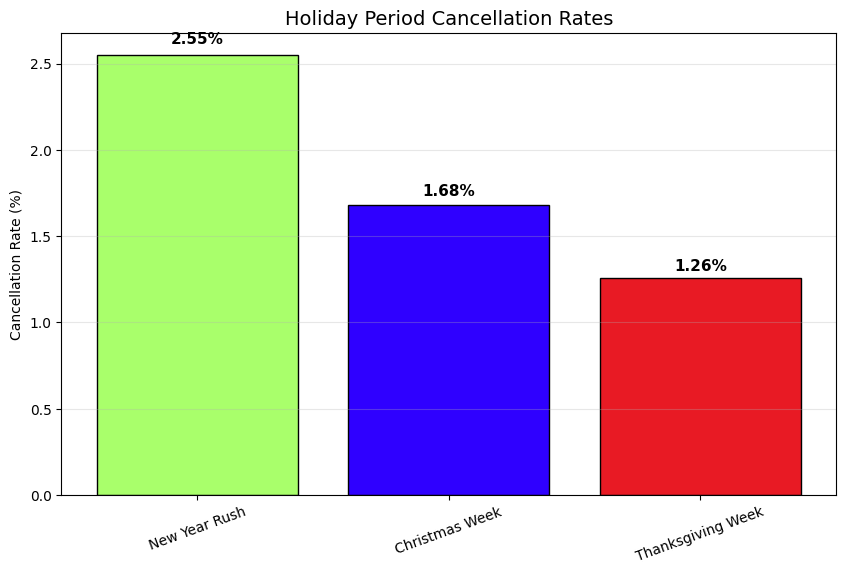

In [136]:
plt.figure(figsize=(10,6))

colors = ["#A9FF6B", "#2F00FF", "#E81A24"]  # bright colors
bars = plt.bar(holiday_df.index, holiday_df['Cancellation Rate (%)'], 
               color=colors, edgecolor='black')

plt.title("Holiday Period Cancellation Rates", fontsize=14)
plt.ylabel("Cancellation Rate (%)")
plt.grid(axis='y', alpha=0.3)

# FIX: place labels very close to the bar top
for i, value in enumerate(holiday_df['Cancellation Rate (%)']):
    plt.text(
        i,
        value + (value * 0.02),      # tiny offset above bar
        f"{value:.2f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.xticks(rotation=20)
plt.show()


 **Key Insights :**

* **New Year Rush has the highest cancellation rate (2.55%)**, likely due to heavy travel demand and winter weather.
* **Christmas Week shows moderate cancellations (1.68%)**, influenced by both travel volume and seasonal weather.
* **Thanksgiving Week has the lowest rate (1.26%)**, suggesting fewer weather-related disruptions compared to winter holidays.
* Overall, **winter holiday periods experience more cancellations** than other festive periods.


### 5. Top 10 Most Congested Routes

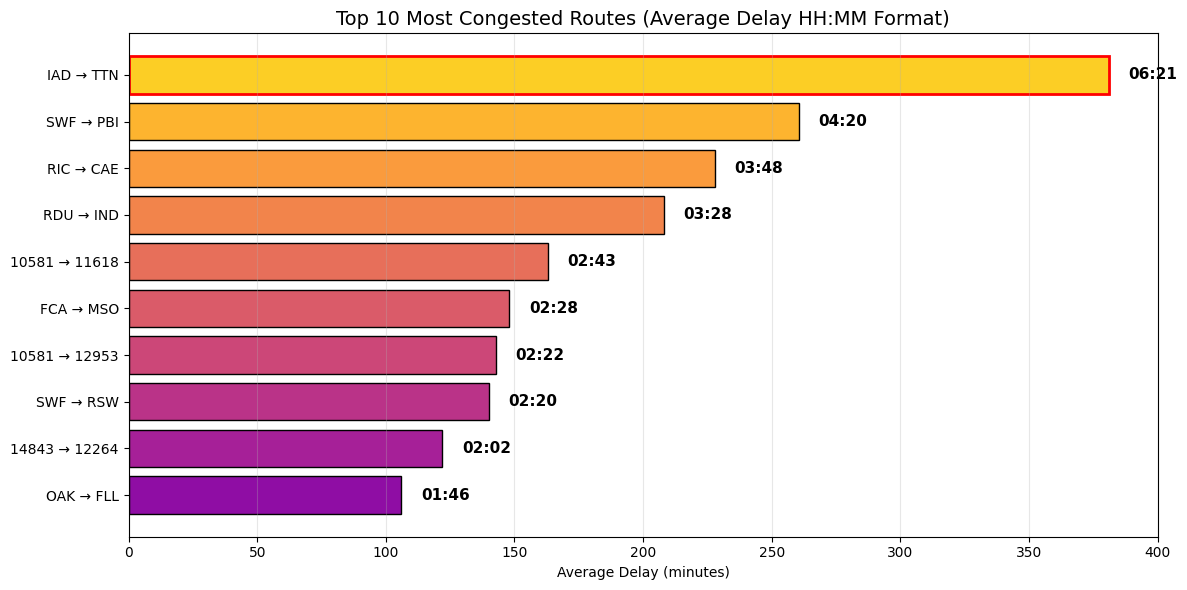

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate top 10 congested routes
route_delay = flights.groupby('ROUTE')['TOTAL_DELAY'].mean().sort_values(ascending=False).head(10)

# Sort for better horizontal display
route_delay = route_delay.sort_values(ascending=True)

# Function to convert minutes → HH:MM format
def minutes_to_hhmm(minutes):
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    return f"{hours:02d}:{mins:02d}"

# Create a formatted version for labels
delay_hhmm = route_delay.apply(minutes_to_hhmm)

plt.figure(figsize=(12,6))

# Bright gradient color palette
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(route_delay)))

bars = plt.barh(route_delay.index, route_delay.values, 
                color=colors, edgecolor='black')

plt.title("Top 10 Most Congested Routes (Average Delay HH:MM Format)", fontsize=14)
plt.xlabel("Average Delay (minutes)")
plt.grid(axis='x', alpha=0.3)

# Add HH:MM labels on bars
for i, (value, label) in enumerate(zip(route_delay.values, delay_hhmm.values)):
    plt.text(
        value + max(route_delay.values)*0.02,
        i,
        label,                       # HH:MM label
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Highlight the worst route with red border
bars[-1].set_edgecolor('red')
bars[-1].set_linewidth(2)

plt.tight_layout()
plt.show()


**Key Insights:**

* **IAD → TTN** is the most congested route with the **highest average delay (06:21 hrs)**, far above all others.
* **SWF → PBI** and **RIC → CAE** follow with long delays of **04:20 hrs** and **03:48 hrs**, showing significant operational issues.
* Many routes experience delays between **2 to 3 hours**, indicating consistent congestion across several city pairs.
* The large gap between the top route and the rest suggests **severe route-specific bottlenecks** on IAD → TTN.
* Overall, these routes represent the **least reliable connections** due to prolonged average delays.


### 6. Weather Delay Trend by month

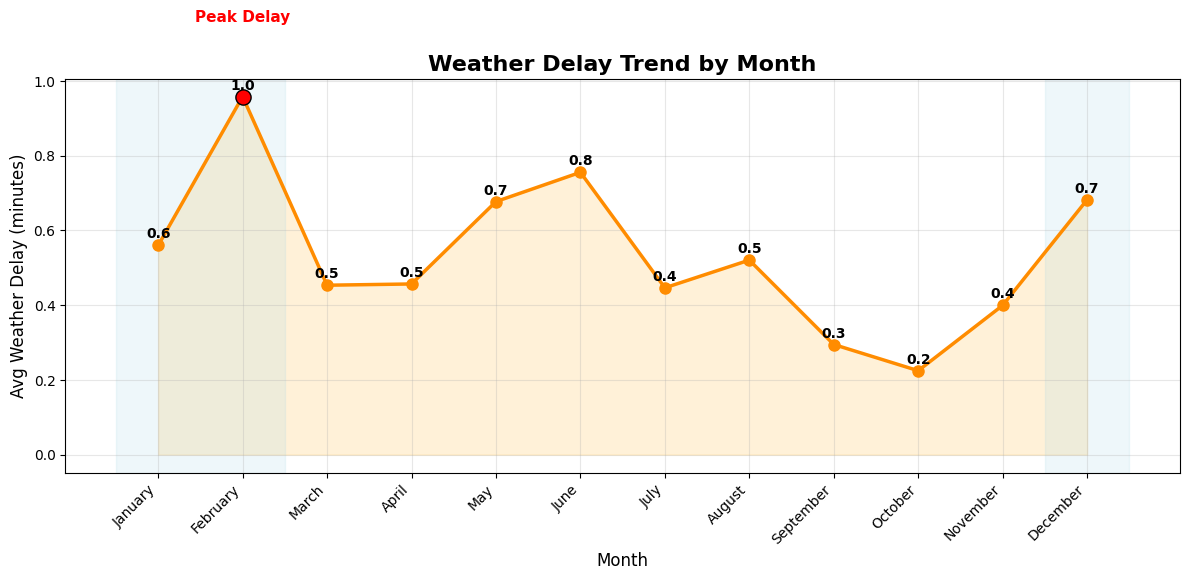

In [139]:
# Ensure month order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

weather_vs_cancel = (
    flights.groupby('MONTH_NAME')['WEATHER_DELAY']
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

# Gradient color style for the line
x = np.arange(len(weather_vs_cancel))
colors = plt.cm.Wistia(np.linspace(0.2, 1, len(weather_vs_cancel)))

plt.plot(x, weather_vs_cancel.values, 
         color='#FF8C00', linewidth=2.5, marker='o', markersize=8)

# Fill under curve for better aesthetics
plt.fill_between(x, weather_vs_cancel.values, color='#FFD27F', alpha=0.3)

# Add value labels above markers
for i, value in enumerate(weather_vs_cancel.values):
    plt.text(i, value + max(weather_vs_cancel.values)*0.02,
             f"{value:.1f}", 
             ha='center', fontsize=10, fontweight='bold')

# Title & labels
plt.title("Weather Delay Trend by Month", fontsize=16, fontweight='bold')
plt.ylabel("Avg Weather Delay (minutes)", fontsize=12)
plt.xlabel("Month", fontsize=12)

# Winter shading (optional but useful)
plt.axvspan(0 - 0.5, 1 + 0.5, color="#ADD8E6", alpha=0.2)  # Jan–Feb
plt.axvspan(11 - 0.5, 11 + 0.5, color="#ADD8E6", alpha=0.2)  # Dec

# Highlight the month with worst weather delays
max_idx = weather_vs_cancel.values.argmax()
plt.scatter(max_idx, weather_vs_cancel.values[max_idx],
            color='red', s=120, edgecolor='black', zorder=5)
plt.text(max_idx, weather_vs_cancel.values[max_idx] + 0.2,
         "Peak Delay", ha='center', fontsize=11, fontweight='bold', color='red')

# Clean formatting
plt.xticks(x, month_order, rotation=45, ha='right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Key Insights (Short & Simple)**

* **February has the highest weather delays (1.0 min)**, indicating peak weather-related disruptions during winter.
* **June and May also show higher delays**, likely due to early summer storms.
* **October and September have the lowest delays**, indicating the most stable and predictable weather.
* **Delays rise again in December**, showing winter conditions beginning to impact flights.
* Overall, **weather delays peak in winter**, dip in early fall, and increase again toward summer and early winter.


### 7. Airline Performance: Delay and Cancellation

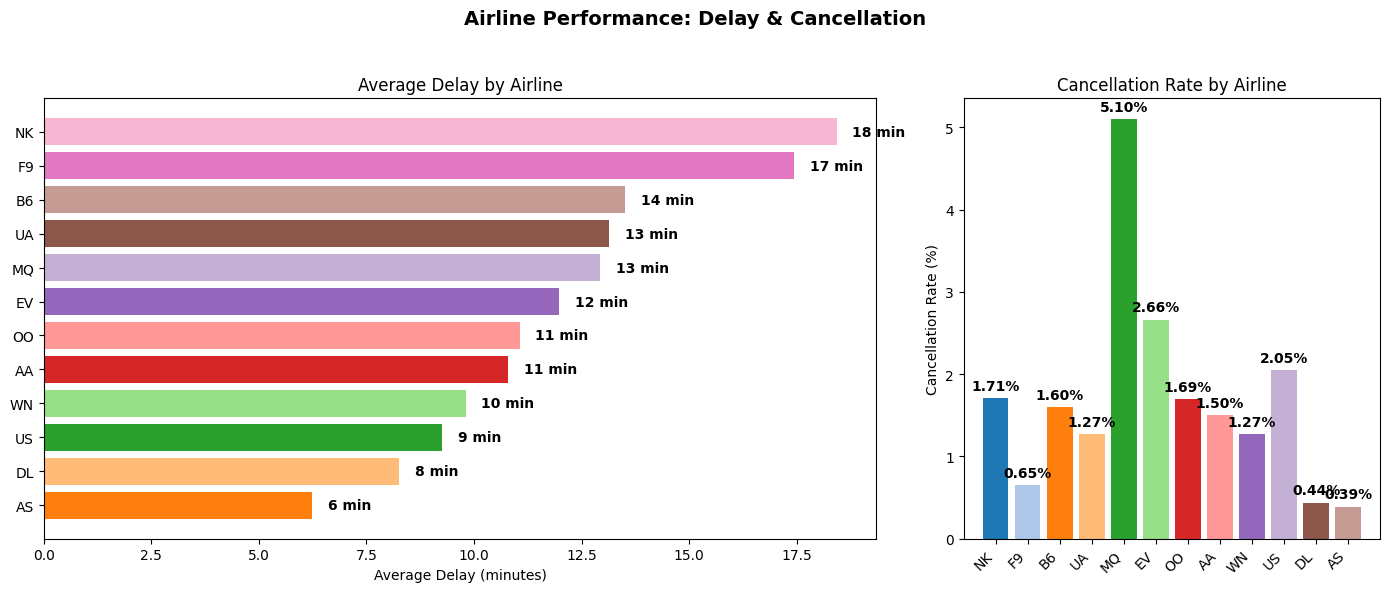

In [141]:
# ---- CONFIG ----
top_n = 12            # how many airlines to display
delay_col = 'TOTAL_DELAY'   # fallback if you want to use TOTAL_DELAY
cancel_col = 'CANCELLED'
airline_col = 'AIRLINE'
figsize = (14,6)
palette = plt.cm.tab20.colors

# ---- PREP ----
df = flights.copy()
# ensure numeric
df[delay_col] = pd.to_numeric(df[delay_col], errors='coerce')
df[cancel_col] = pd.to_numeric(df[cancel_col], errors='coerce').fillna(0)

# get airlines with most flights (to show representative performers)
airline_counts = df[airline_col].value_counts().head(100)   # top carriers by sample
top_airlines = airline_counts.index[:top_n].tolist()

agg = df[df[airline_col].isin(top_airlines)].groupby(airline_col).agg(
    avg_delay = (delay_col, 'mean'),
    cancel_rate = (cancel_col, 'mean'),
    flights = (airline_col, 'count')
).sort_values('avg_delay', ascending=False)

# convert cancel_rate to percent
agg['cancel_pct'] = agg['cancel_rate'] * 100

# ---- PLOT ----
fig, axes = plt.subplots(1,2, figsize=figsize, gridspec_kw={'width_ratios':[2,1]})

# A) Avg delay (horizontal)
ax = axes[0]
bars = ax.barh(agg.index[::-1], agg['avg_delay'][::-1], color=palette[:len(agg)])
ax.set_xlabel("Average Delay (minutes)")
ax.set_title("Average Delay by Airline")
for i, v in enumerate(agg['avg_delay'][::-1]):
    ax.text(v + max(agg['avg_delay']) * 0.02, i, f"{v:.0f} min", va='center', fontweight='bold')

# B) Cancellation rate (vertical)
ax2 = axes[1]
ax2.bar(agg.index, agg['cancel_pct'], color=palette[:len(agg)])
ax2.set_xticklabels(agg.index, rotation=45, ha='right')
ax2.set_ylabel("Cancellation Rate (%)")
ax2.set_title("Cancellation Rate by Airline")
for i, v in enumerate(agg['cancel_pct']):
    ax2.text(i, v + (max(agg['cancel_pct']) * 0.02), f"{v:.2f}%", ha='center', fontweight='bold')

plt.suptitle("Airline Performance: Delay & Cancellation", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


### **Average Delay by Airline**

* **NK, F9, and B6** have the **highest delays** (14–18 minutes), making them the least punctual.
* **UA, MQ, EV** show mid-range delays around 12–13 minutes.
* **AA, WN, US, DL, and AS** have relatively **lower delays** (6–11 minutes), with **AS being the best performer** (only 6 minutes).

### **Cancellation Rate by Airline**

* **MQ has the highest cancellation rate (5.10%)**, indicating operational consistency issues.
* **EV (2.66%)** and **OO (2.05%)** also show elevated cancellation rates.
* **Most major carriers like AA, B6, UA, WN** maintain **stable cancellation rates around 1–1.7%**.
* **DL and AS have the lowest cancellation rates (<0.5%)**, showing strong reliability.

### **Overall Performance**

* **Best performers:** AS and DL — low delays + minimal cancellations.
* **Worst performers:** NK and F9 in delay, MQ in cancellations.


### 8. Monthly Average Flight Delays at Major U.S. Airports

In [150]:
# Robust heatmap (fixes KeyError when AIRPORT_ID missing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# CONFIG
top_k = 12
delay_prefer = 'TOTAL_DELAY'  # fallback to DEPARTURE_DELAY if missing
label_max_len = 30

# Copy inputs
airp = airports.copy()
fl = flights.copy()

# Normalize airport table columns (if present)
for c in ['IATA_CODE', 'AIRPORT', 'CITY', 'AIRPORT_ID']:
    if c in airp.columns:
        airp[c] = airp[c].astype(str).str.strip()
# Uppercase IATA codes for safe matching
if 'IATA_CODE' in airp.columns:
    airp['IATA_CODE'] = airp['IATA_CODE'].str.upper()

# Quick diagnostic
print("airports columns:", list(airp.columns))
print("flights sample ORIGIN_AIRPORT values:", fl['ORIGIN_AIRPORT'].dropna().astype(str).unique()[:10])

# Determine whether origin values look numeric
orig_sample = fl['ORIGIN_AIRPORT'].dropna().astype(str).str.strip().head(50).unique()
uses_numeric_ids = len(orig_sample) > 0 and np.all([s.isdigit() for s in orig_sample])

# Decide mapping approach
has_airport_id_col = 'AIRPORT_ID' in airp.columns
print(f"Detected numeric-like origins: {uses_numeric_ids}, airports has AIRPORT_ID column: {has_airport_id_col}")

# Attempt merge
if uses_numeric_ids and has_airport_id_col:
    # Map by numeric AIRPORT_ID
    print("Mapping by numeric AIRPORT_ID -> AIRPORT/CITY/IATA")
    airp['AIRPORT_ID_NUM'] = pd.to_numeric(airp['AIRPORT_ID'], errors='coerce')
    fl['ORIGIN_AIRPORT_NUM'] = pd.to_numeric(fl['ORIGIN_AIRPORT'], errors='coerce')
    cols = ['AIRPORT_ID_NUM', 'IATA_CODE', 'AIRPORT', 'CITY']
    airp_sel = airp[cols].rename(columns={'AIRPORT_ID_NUM': 'AIRPORT_ID_NUM'})
    fl = fl.merge(airp_sel, left_on='ORIGIN_AIRPORT_NUM', right_on='AIRPORT_ID_NUM', how='left')
    fl['IATA_MATCHED'] = fl['IATA_CODE']  # may be NaN
else:
    # Map by IATA code if possible
    print("Attempting mapping by IATA_CODE -> AIRPORT/CITY")
    fl['ORIGIN_AIRPORT'] = fl['ORIGIN_AIRPORT'].astype(str).str.strip().str.upper()
    if 'IATA_CODE' in airp.columns:
        matches = set(airp['IATA_CODE'].unique()).intersection(set(fl['ORIGIN_AIRPORT'].unique()))
    else:
        matches = set()
    if len(matches) > 0:
        print("Found overlapping IATA codes; merging by IATA_CODE.")
        airp_sel = airp[['IATA_CODE', 'AIRPORT', 'CITY']].drop_duplicates()
        fl = fl.merge(airp_sel, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
        fl['IATA_MATCHED'] = fl['IATA_CODE']
    else:
        # No direct mapping - attach airport info where possible, otherwise leave NaN
        print("No matching IATA codes found. We will keep ORIGIN_AIRPORT and fill unknowns later.")
        airp_sel = airp[['IATA_CODE', 'AIRPORT', 'CITY']].drop_duplicates() if 'IATA_CODE' in airp.columns else pd.DataFrame()
        # try a merge (will mostly produce NaNs), safe to run
        if not airp_sel.empty:
            fl = fl.merge(airp_sel, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
        else:
            fl['AIRPORT'] = np.nan
            fl['CITY'] = np.nan
        fl['IATA_MATCHED'] = fl.get('IATA_CODE', np.nan)

# Build CITY — IATA label with fallbacks
def make_city_iata(row):
    city = row.get('CITY')
    # prefer a matched IATA code from airports; else use original ORIGIN_AIRPORT
    iata = row.get('IATA_MATCHED') if pd.notna(row.get('IATA_MATCHED')) else row.get('ORIGIN_AIRPORT')
    city = city if pd.notna(city) and str(city).strip().lower() not in ['nan', 'none'] else None
    iata = str(iata).strip() if pd.notna(iata) and str(iata).strip() != 'nan' else None
    if city and iata:
        return f"{city} — {iata}"
    if city:
        return f"{city} — UNK"
    if iata:
        # if iata looks numeric and not useful, we'll mark it later
        return f"{iata}"
    return "Unknown Airport"

fl['AIRPORT_LABEL'] = fl.apply(make_city_iata, axis=1)

# Replace purely numeric labels (like '14222') with nicer placeholders
def is_pure_number(s):
    try:
        return str(s).strip().isdigit()
    except:
        return False

# Build unknown map for numeric-only labels
unique_labels = fl['AIRPORT_LABEL'].astype(str).unique()
unknown_map = {}
cnt = 0
for lab in unique_labels:
    if is_pure_number(lab):
        unknown_map[lab] = f"Unknown Airport {chr(65 + cnt)}"
        cnt += 1

fl['AIRPORT_LABEL'] = fl['AIRPORT_LABEL'].replace(unknown_map)

# Shorten label for plotting
def shorten(s, mx=label_max_len):
    s = str(s)
    return s if len(s) <= mx else s[:mx-3].rstrip() + '...'

fl['AIRPORT_LABEL_SHORT'] = fl['AIRPORT_LABEL'].apply(lambda x: shorten(x, label_max_len))

# Ensure a month numeric column
if 'MONTH' in fl.columns:
    fl['MONTH_NUM'] = pd.to_numeric(fl['MONTH'], errors='coerce').astype('Int64')
else:
    fl['MONTH_NUM'] = pd.to_datetime(fl.get('DATE'), errors='coerce').dt.month

# Select delay column
if delay_prefer in fl.columns:
    delay_col = delay_prefer
elif 'DEPARTURE_DELAY' in fl.columns:
    delay_col = 'DEPARTURE_DELAY'
else:
    raise ValueError("No TOTAL_DELAY or DEPARTURE_DELAY column found. Create TOTAL_DELAY or include DEPARTURE_DELAY.")

fl[delay_col] = pd.to_numeric(fl[delay_col], errors='coerce').fillna(0)

# Choose top_k airports by flight count
top_airports = fl['AIRPORT_LABEL_SHORT'].value_counts().head(top_k).index.tolist()

pivot = (
    fl[fl['AIRPORT_LABEL_SHORT'].isin(top_airports)]
      .groupby(['MONTH_NUM', 'AIRPORT_LABEL_SHORT'])[delay_col]
      .mean()
      .unstack(fill_value=0)
      .reindex(index=range(1,13), columns=top_airports, fill_value=0)
)


airports columns: ['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']
flights sample ORIGIN_AIRPORT values: ['ANC' 'LAX' 'SFO' 'SEA' 'LAS' 'DEN' 'SLC' 'PDX' 'FAI' 'MSP']
Detected numeric-like origins: False, airports has AIRPORT_ID column: False
Attempting mapping by IATA_CODE -> AIRPORT/CITY
Found overlapping IATA codes; merging by IATA_CODE.


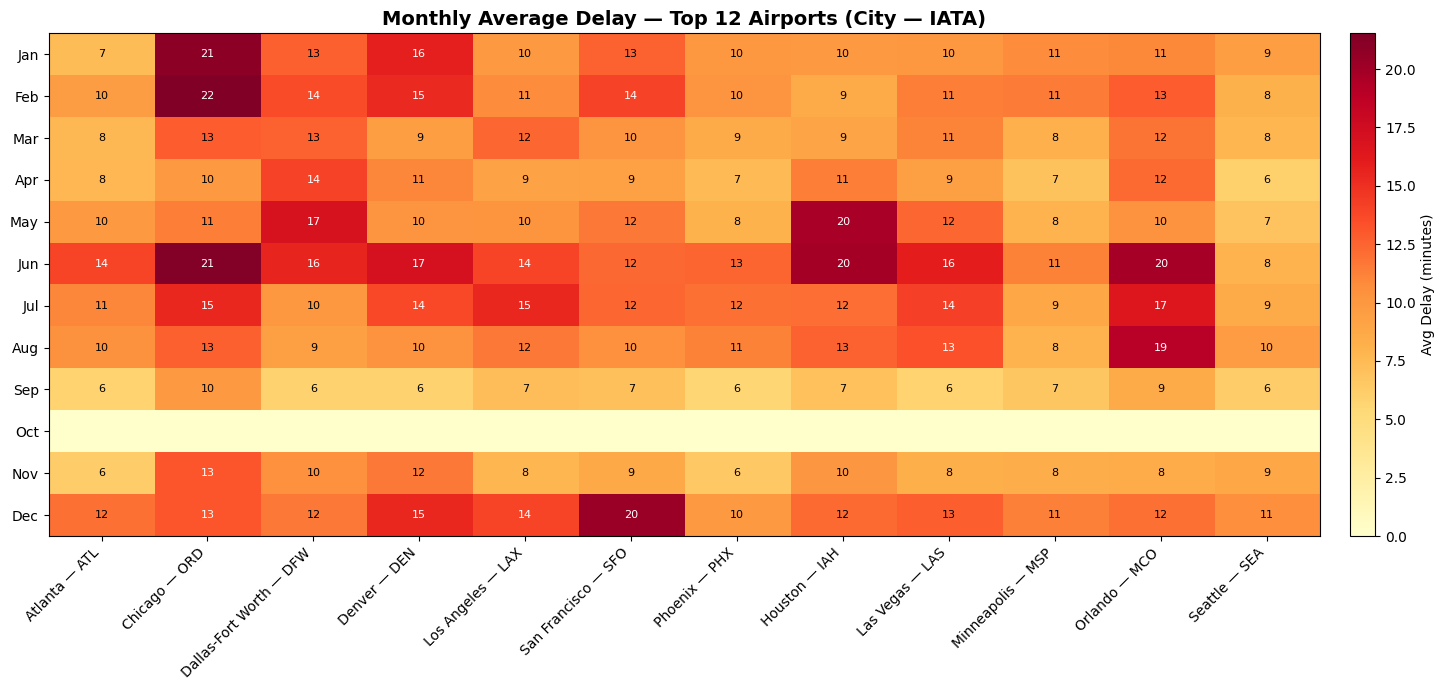

In [151]:

# Plot
plt.figure(figsize=(16,7))
im = plt.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=max(pivot.values.max(), 1))
cbar = plt.colorbar(im, pad=0.02)
cbar.set_label('Avg Delay (minutes)')

month_labels = [calendar.month_abbr[m] for m in pivot.index]
plt.yticks(ticks=np.arange(len(month_labels)), labels=month_labels, fontsize=10)
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right', fontsize=10)
plt.title(f"Monthly Average Delay — Top {len(pivot.columns)} Airports (City — IATA)", fontsize=14, fontweight='bold')

# Annotate
max_val = pivot.values.max()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iat[i, j]
        if not np.isnan(val) and val > 0:
            txt_color = 'white' if val > (0.6 * max_val) else 'black'
            plt.text(j, i, f"{val:.0f}", ha='center', va='center', color=txt_color, fontsize=8)

plt.tight_layout()
plt.show()

# Optional: persist enriched flights back to workspace
# flights = fl


### **KEY INSIGHTS:**:
* **Chicago (ORD)** shows the highest delays year-round, especially in winter and early summer.
* **Atlanta (ATL)** and **Minneapolis (MSP)** are the most efficient, with consistently low delays.
* **Dallas–Fort Worth (DFW)**, **Denver (DEN)**, and **Las Vegas (LAS)** see noticeable delay peaks in summer.
* **Houston (IAH)** and **Orlando (MCO)** experience mid-year spikes due to storms and tourist travel.
* **San Francisco (SFO)** maintains steady moderate delays, influenced by fog and runway limits.
* Overall delay patterns follow seasons, with **winter and summer** being the most delay-prone periods and **fall** showing the lowest delays across airports.

### Milestone 4: Report and Presentation 

Week 7: Visual Report or Dashboard Preparation 

• Combine plots into a coherent storyline 

• Use markdown, presentation slides, or Streamlit 

• Ensure plots include labels, titles, legends, and axis clarity 

Week 8: Documentation and Final Presentation 

• Create final report (PDF or README) 

• Build slide deck for presentation 

• Record insights and visual walkthrough 

Deliverables: 

• Final report or dashboard 

• Slide deck 

• GitHub repository with code and visuals 